In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as stats
import os
import sys
from IPython.display import display

# 0. loading of all necessary tables and creation of structured tables

In [5]:
# Add the path to the directory containing your the csv's
file_path_small = "../../MIALAB Workspace/new results/small_labels_2024-12-05-00-02-20/small_labels_results.csv" 
data_small = pd.read_csv(file_path_small, delimiter = ';')

file_path_large = "../../MIALAB Workspace/new results/large_labels_2024-12-05-00-40-32/large_labels_results.csv"
data_large = pd.read_csv(file_path_large, delimiter = ';')

file_path_all = "../../MIALAB Workspace/new results/all_labels_2024-12-04-23-25-36/all_labels_results.csv"
data_all = pd.read_csv(file_path_all, delimiter = ';')

# only analyse the post processing metrics
data_small_pp = data_small[data_small['SUBJECT'].str.contains('PP')].copy()
data_large_pp = data_large[data_large['SUBJECT'].str.contains('PP')].copy()
data_all_pp = data_all[data_all['SUBJECT'].str.contains('PP')].copy()

# Ensure the data is in a suitable format
data_all_pp['Model'] = 'All'
data_small_pp.loc[:, 'Model'] = 'Small'
data_large_pp.loc[:, 'Model'] = 'Large'

#dictionary containing the fully written description of the metric abbreviations
metrics_dict = {
    'SUBJECT': 'Subject',
    'LABEL': 'Label',
    'ADJRIND': 'Adjusted Rand Index',
    'AUC': 'Area Under Curve',
    'AVGDIST': 'Average Distance',
    'DICE': 'Dice Coefficient',
    'FN': 'False Negatives',
    'FP': 'False Positives',
    'HDRFDST': 'Hausdorff Distance',
    'JACRD': 'Jaccard Index',
    'MUTINF': 'Mutual Information',
    # 'PRCISON': 'Precision',
    'RNDIND': 'Rand Index',
    'SNSVTY': 'Sensitivity',
    'SPCFTY': 'Specificity',
    'TN': 'True Negatives',
    'TP': 'True Positives',
    'VOLSMTY': 'Volume Similarity'}

# Define the metrics categories
metrics_overlap = ['Dice Coefficient', 'Jaccard Index', 'Sensitivity', 'Specificity'] # overlap based
metrics_volume = ['Volume Similarity'] # volume based
metrics_pairs = ['Adjusted Rand Index','Rand Index'] # pair based
metrics_information = ['Mutual Information'] # information based
metrics_probability = ['Area Under Curve'] # probability based
metrics_distance = ['Average Distance', 'Hausdorff Distance'] # distance based
metrics_confusion = ['False Negatives', 'False Positives', 'True Negatives', 'True Positives'] # confusion matrix based

metrics_categories = {
    'overlap_based': metrics_overlap,
    'volume_based': metrics_volume,
    'pair_based': metrics_pairs,
    'information_based': metrics_information,
    'probability_based': metrics_probability,
    'distance_based': metrics_distance,
    'confusion_matrix_based': metrics_confusion
}

differences = {}
for metric in metrics_dict.keys():
    if metric not in ['SUBJECT', 'LABEL']:
        differences[f'{metrics_dict[metric]}_diff_small'] = -(data_all_pp[metric] - data_small_pp[metric])
        differences[f'{metrics_dict[metric]}_diff_large'] = -(data_all_pp[metric] - data_large_pp[metric])
        differences[f'{metrics_dict[metric]}_relative_diff_small'] = -(data_all_pp[metric] - data_small_pp[metric])/data_all_pp[metric]
        differences[f'{metrics_dict[metric]}_relative_diff_large'] = -(data_all_pp[metric] - data_large_pp[metric])/data_all_pp[metric]

diff_df = pd.DataFrame(differences)
diff_df['LABEL'] = data_all['LABEL']
diff_df['SUBJECT'] = data_all['SUBJECT']


diff_small = diff_df[['LABEL', 'SUBJECT'] + [col for col in diff_df.columns if 'small' in col]].copy()
diff_large = diff_df[['LABEL', 'SUBJECT'] + [col for col in diff_df.columns if 'large' in col]].copy()


# Create a dictionary to map each metric to its category
metric_to_category = {}
for category, metrics in metrics_categories.items():
    for metric in metrics:
        metric_to_category[metric] = category

# Group the columns of diff_small and diff_large per metric category
grouped_diff_small = {}
grouped_diff_large = {}

for category in metrics_categories.keys():
    grouped_diff_small[category] = diff_small[['LABEL', 'SUBJECT'] + [col for col in diff_small.columns if any(metric in col for metric in metrics_categories[category])]]
    grouped_diff_large[category] = diff_large[['LABEL', 'SUBJECT'] + [col for col in diff_large.columns if any(metric in col for metric in metrics_categories[category])]]

print(grouped_diff_small.keys())

dict_keys(['overlap_based', 'volume_based', 'pair_based', 'information_based', 'probability_based', 'distance_based', 'confusion_matrix_based'])


In [3]:
# grouped_diff_large['information_based']

# 1. Distribution of metrics for post-processed predictions:

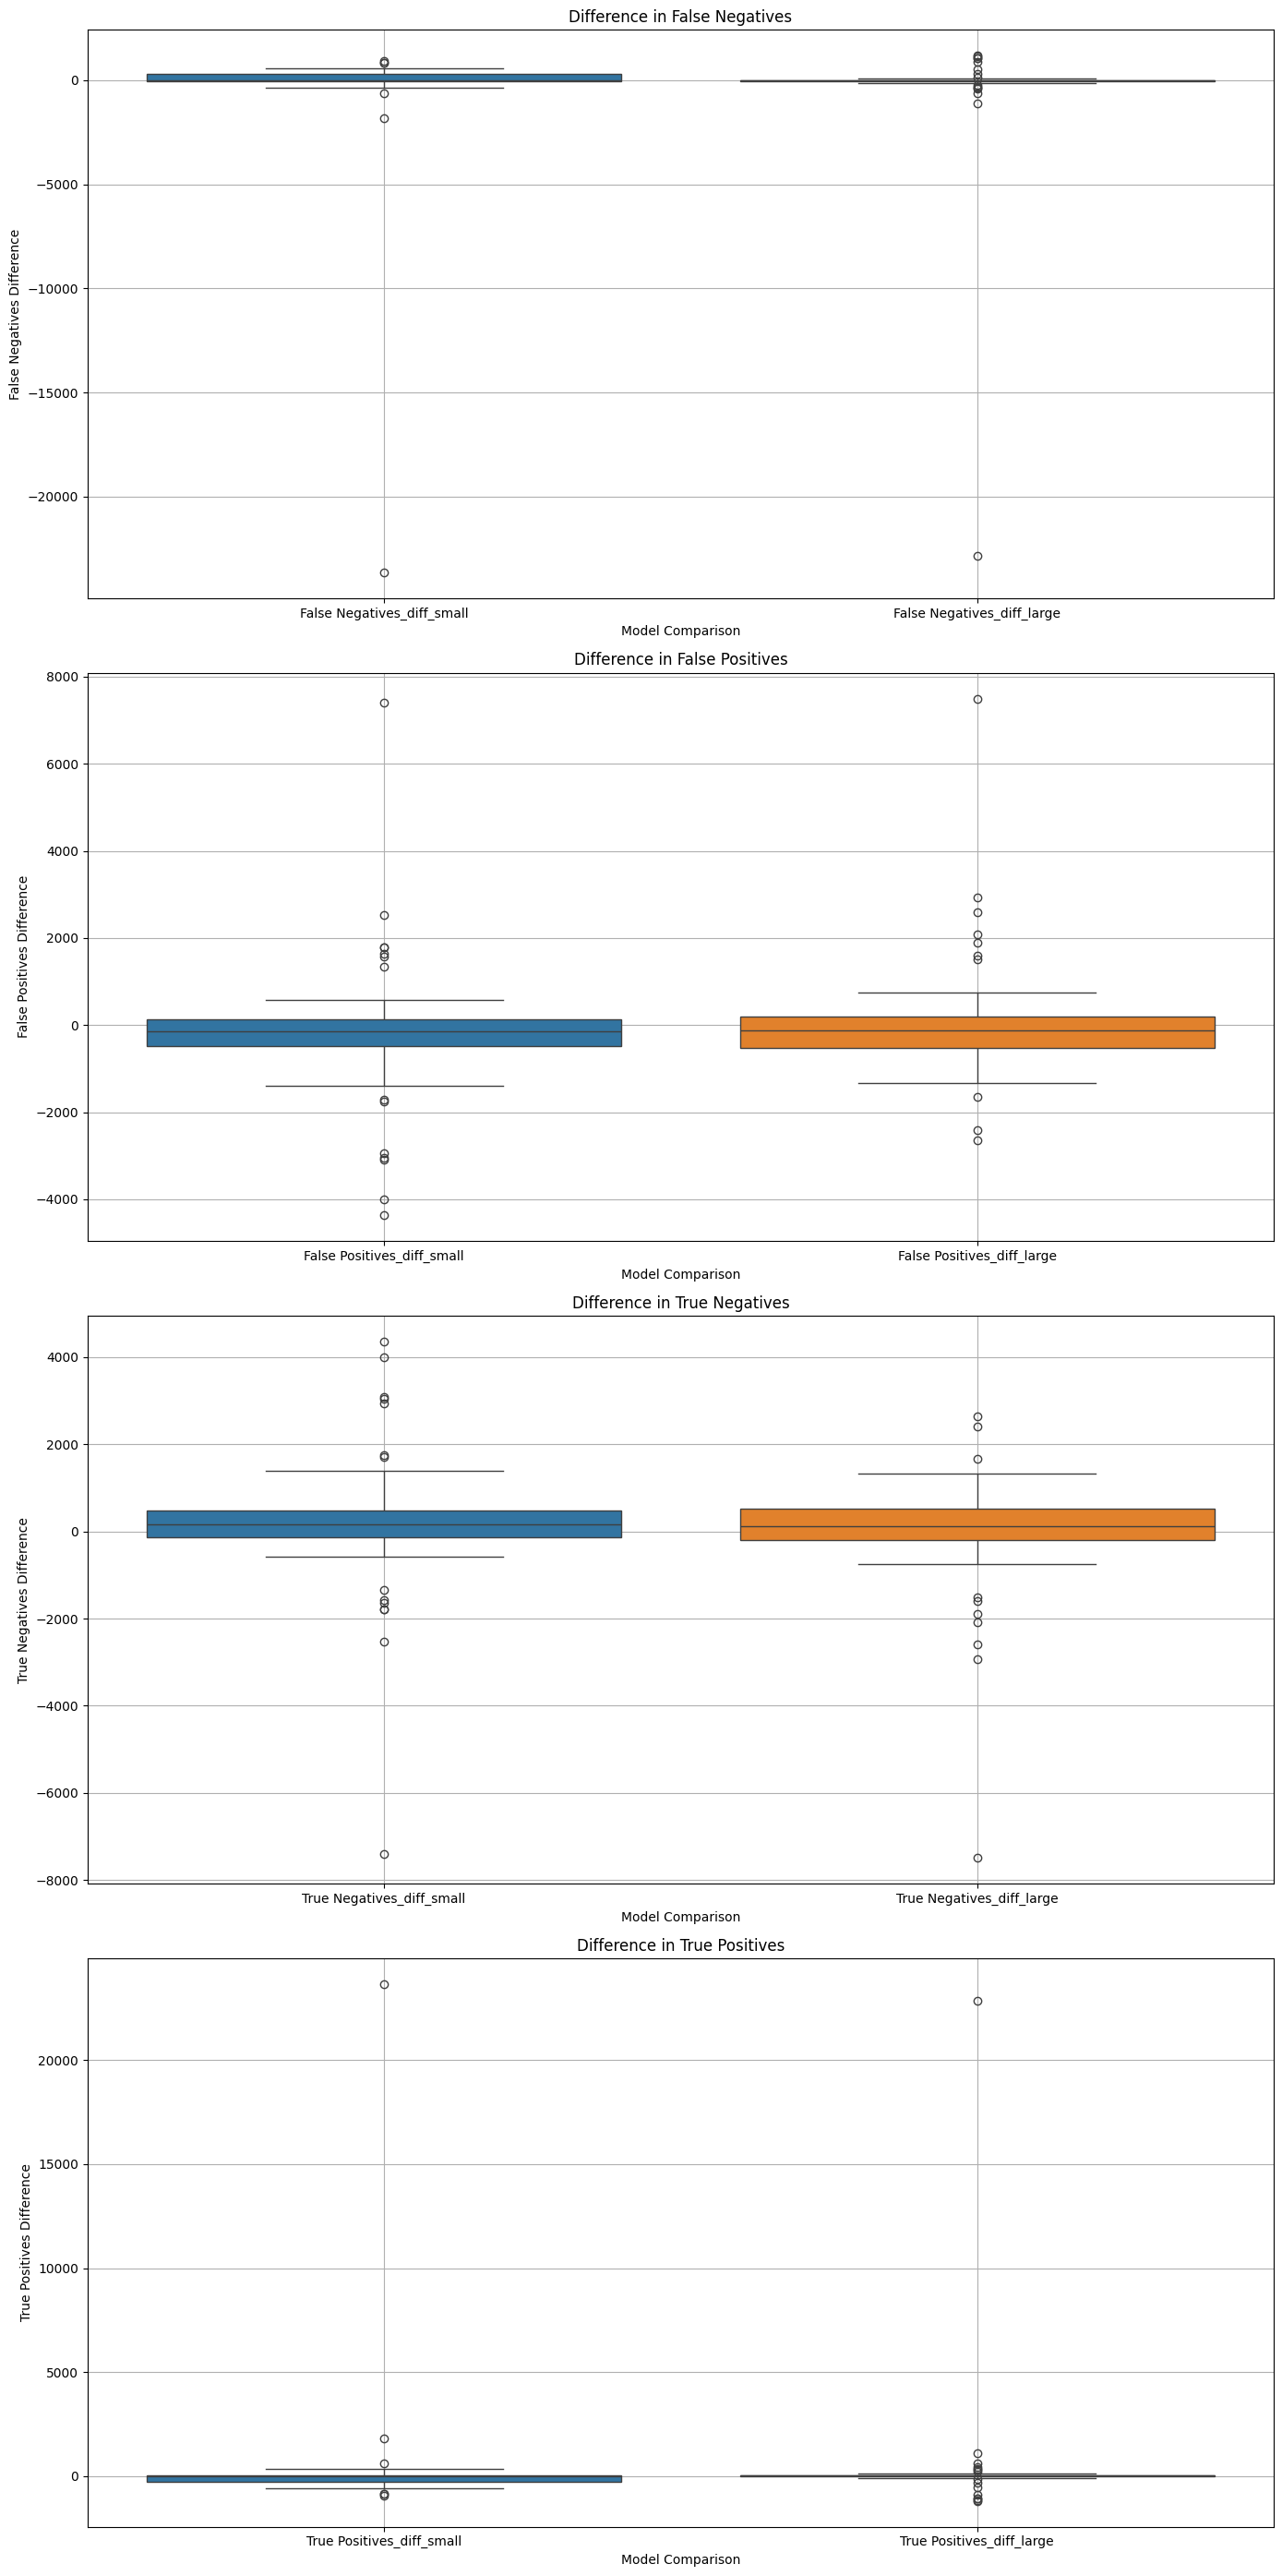

In [4]:

# Visualize the differences

fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 7 * len(metrics)))

# Ensure axes is always a list for consistency
if len(metrics) == 1:
    axes = [axes]

for i, metric in enumerate(metrics):
    sns.boxplot(data=diff_df[[f'{metric}_diff_small', f'{metric}_diff_large']], ax=axes[i])
    axes[i].set_title(f'Difference in {metric}')
    axes[i].set_xlabel('Model Comparison')
    axes[i].set_ylabel(f'{metric} Difference')
    axes[i].grid()
    

plt.tight_layout()
# plt.show()

<Figure size 1400x700 with 0 Axes>

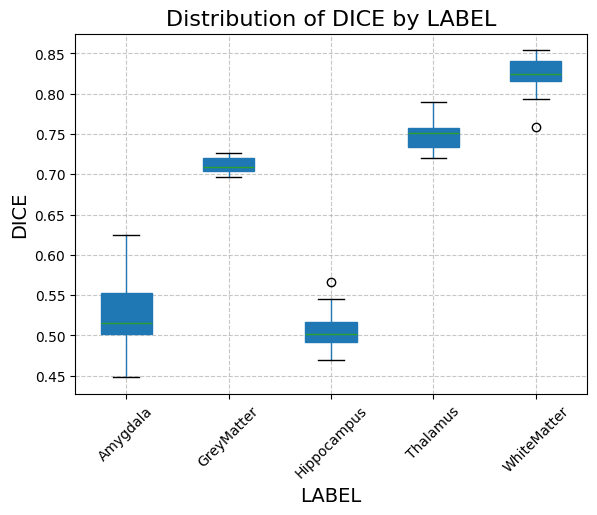

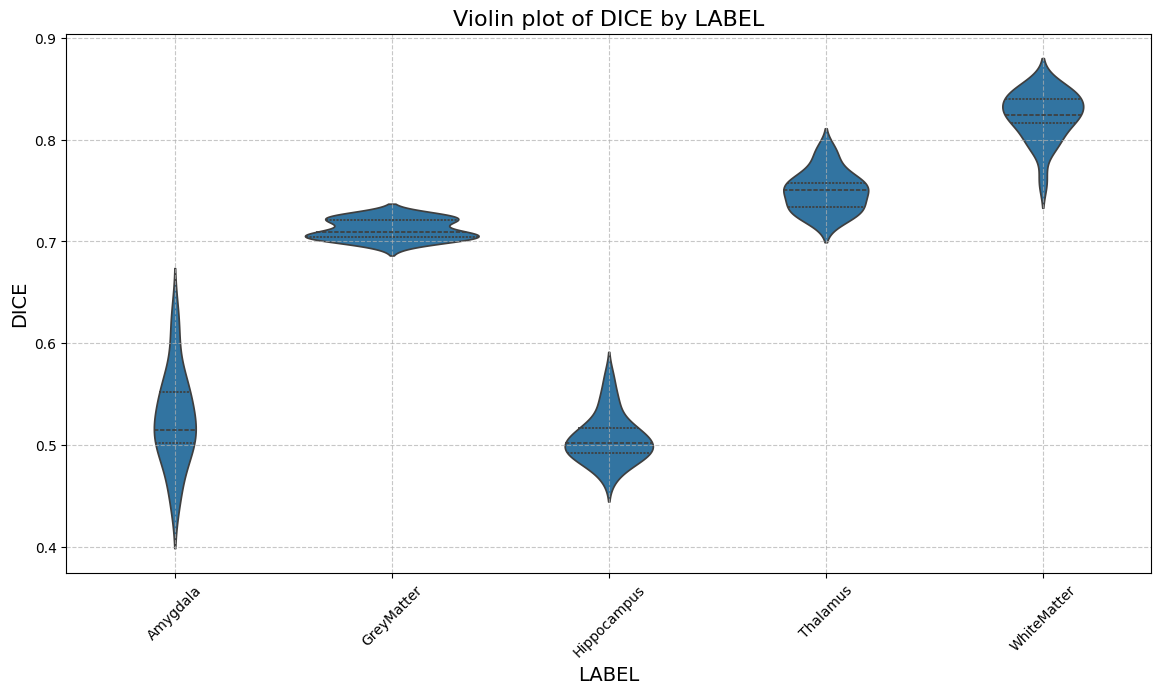

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_metric_distributions(data, metrics):
    for metric in metrics:
        plt.figure(figsize=(14, 7))
        ax = data.boxplot(column=metric, by='LABEL', grid=False, patch_artist=True)
        plt.title(f'Distribution of {metric} by LABEL', fontsize=16)
        plt.suptitle('')  # Suppress the default title to avoid overlap
        plt.xlabel('LABEL', fontsize=14)
        plt.ylabel(metric, fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(True, linestyle='--', alpha=0.7)
plot_metric_distributions(data_small, metrics=['DICE'])   
def plot_violin_plots(data, metrics):
    for metric in metrics:
        plt.figure(figsize=(14, 7))
        sns.violinplot(x='LABEL', y=metric, data=data, inner='quartile')
        plt.title(f'Violin plot of {metric} by LABEL', fontsize=16)
        plt.xlabel('LABEL', fontsize=14)
        plt.ylabel(metric, fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

plot_violin_plots(data_small, metrics=['DICE'])

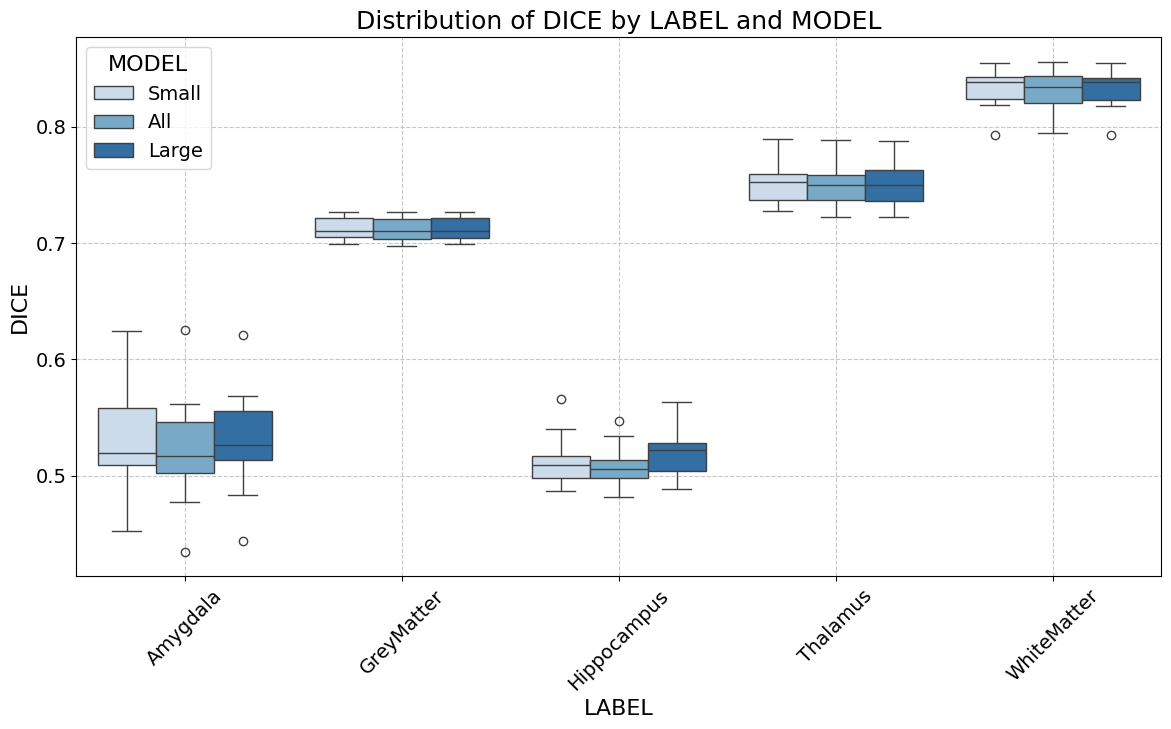

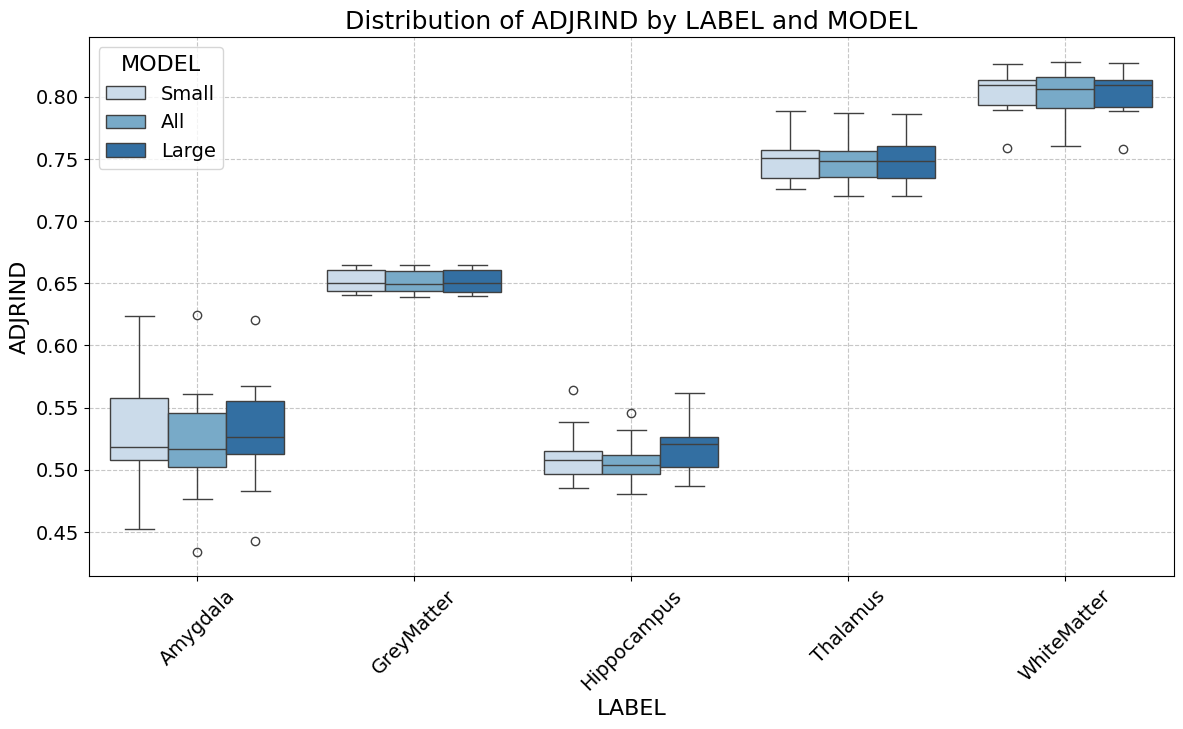

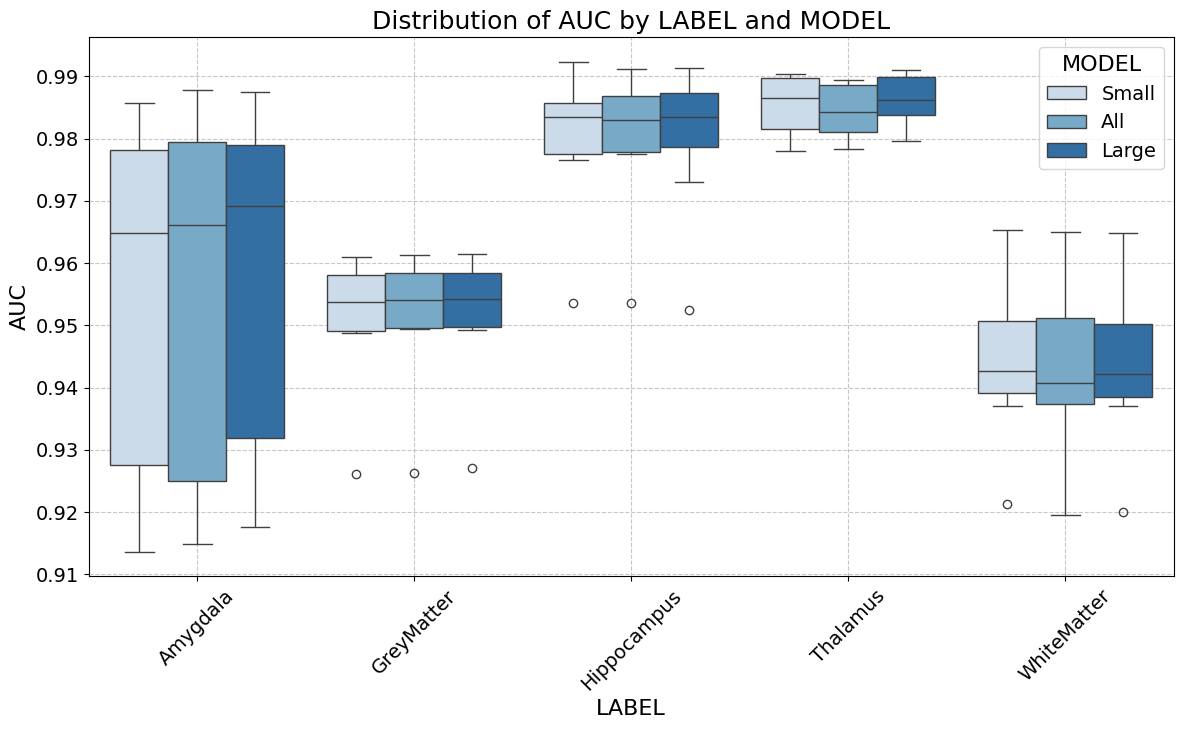

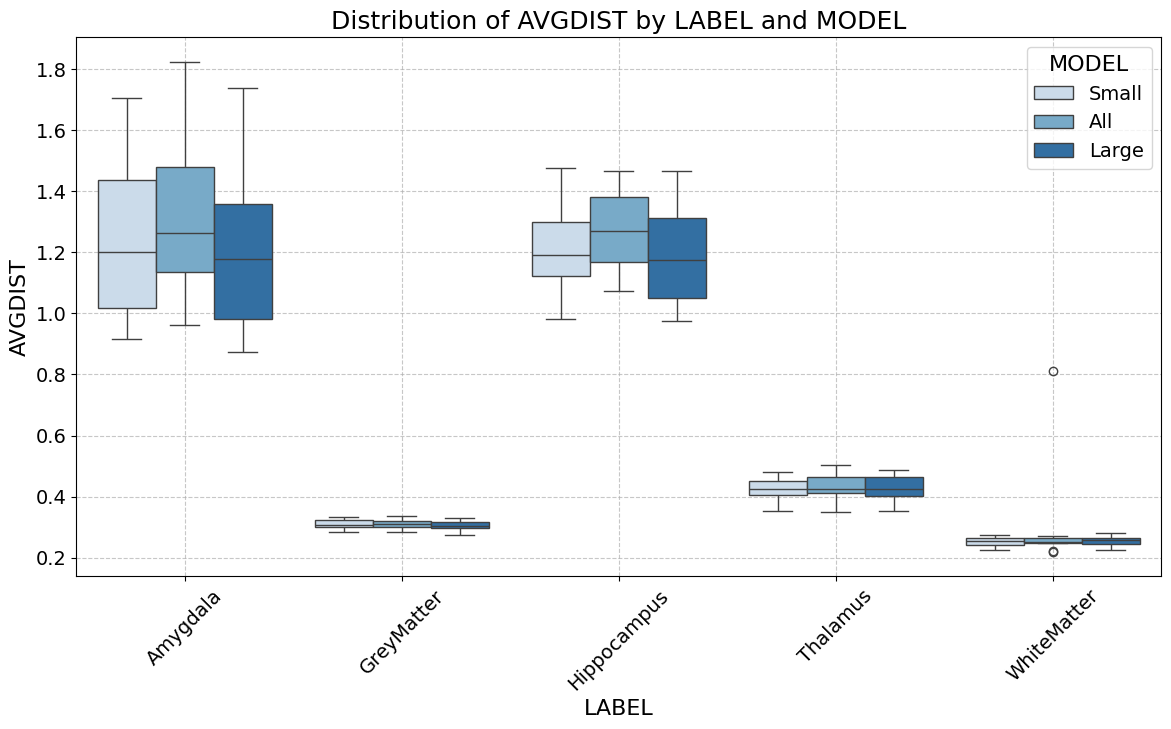

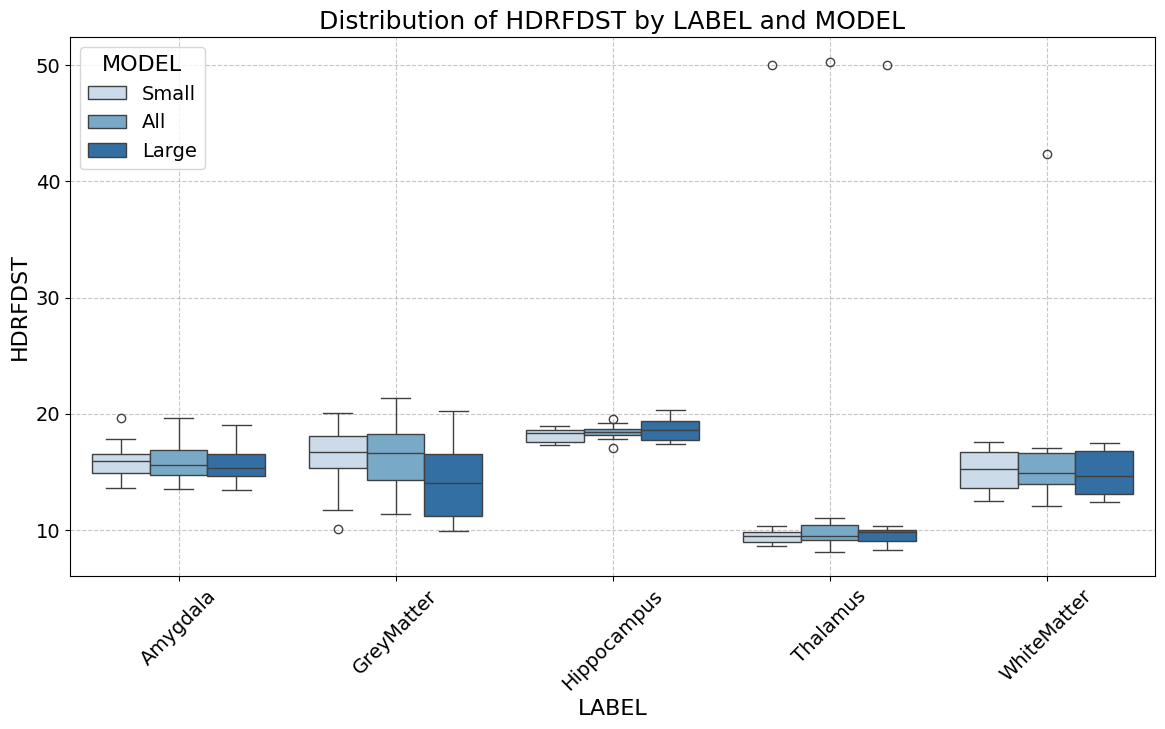

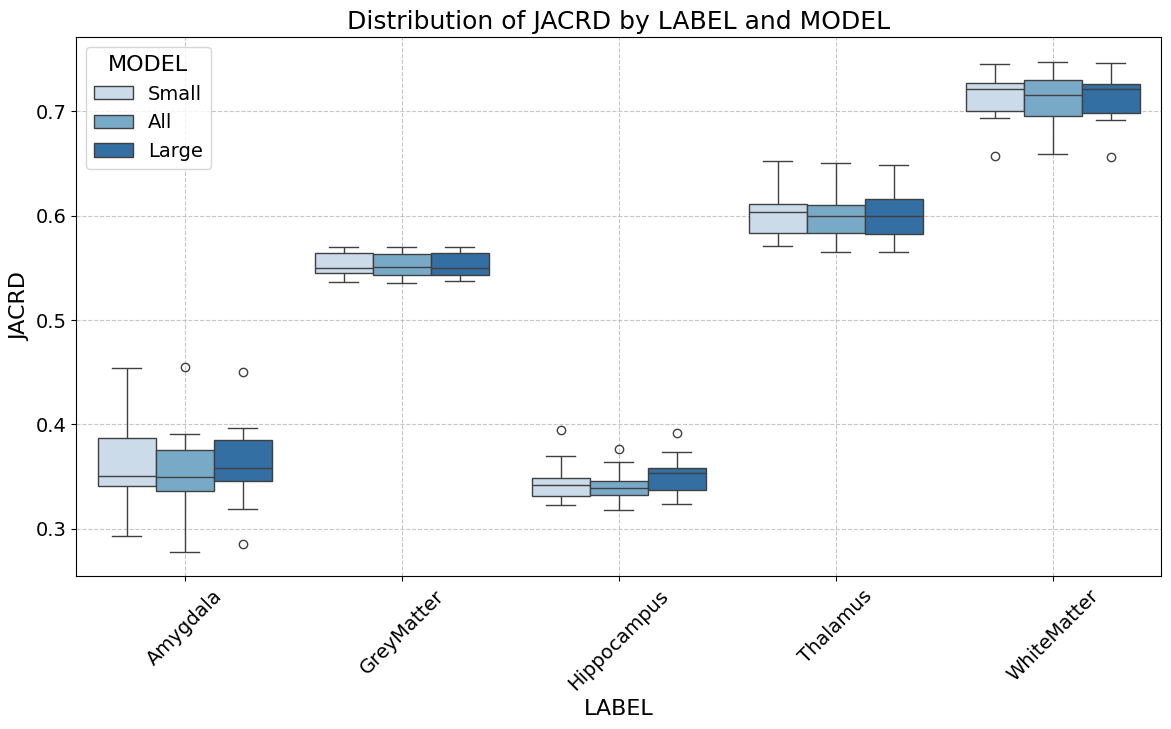

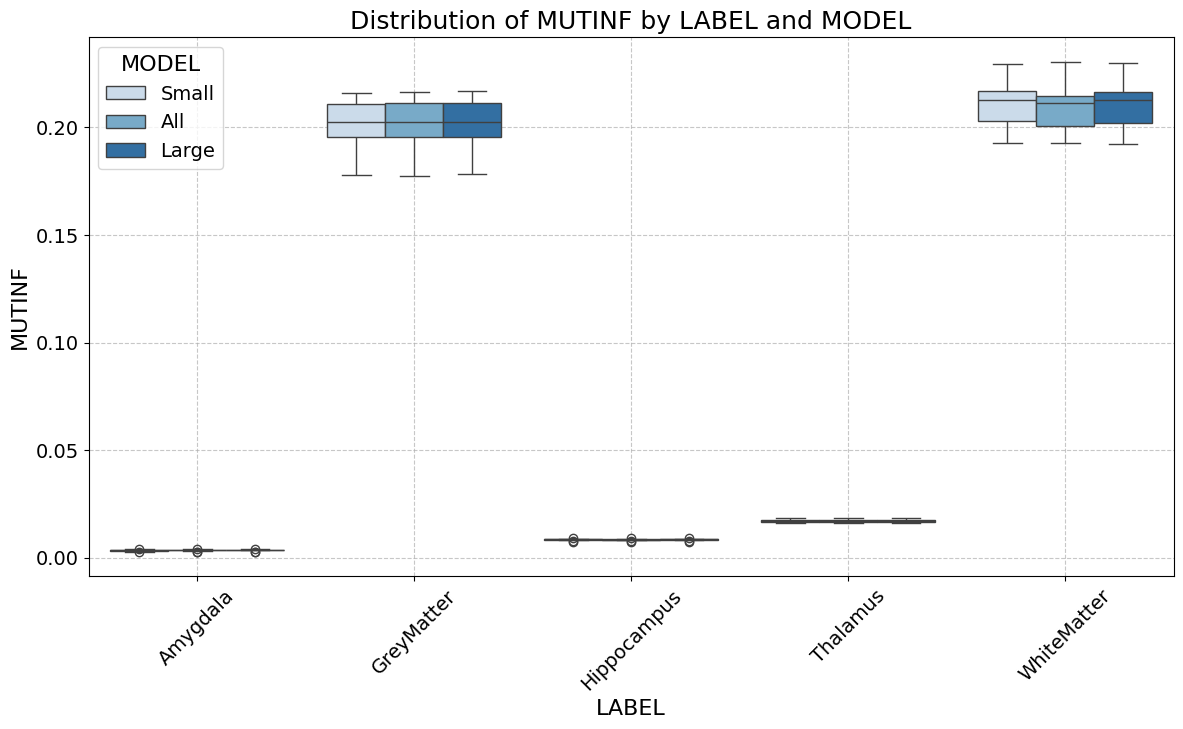

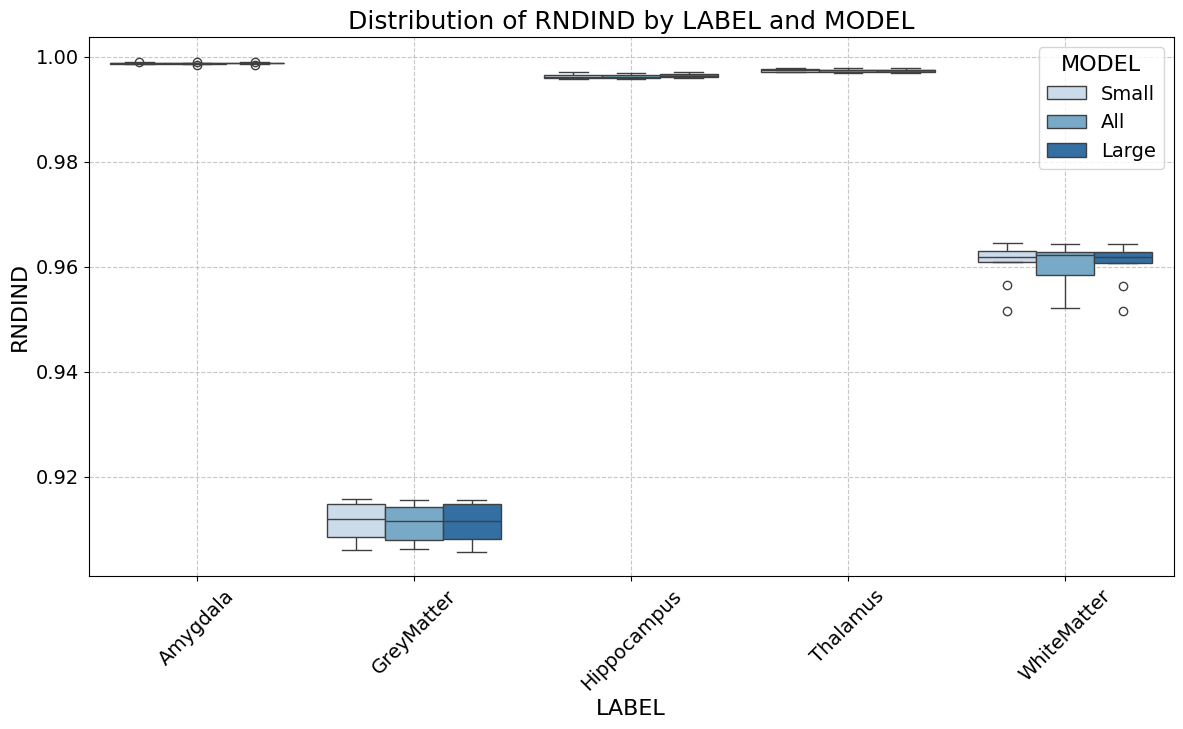

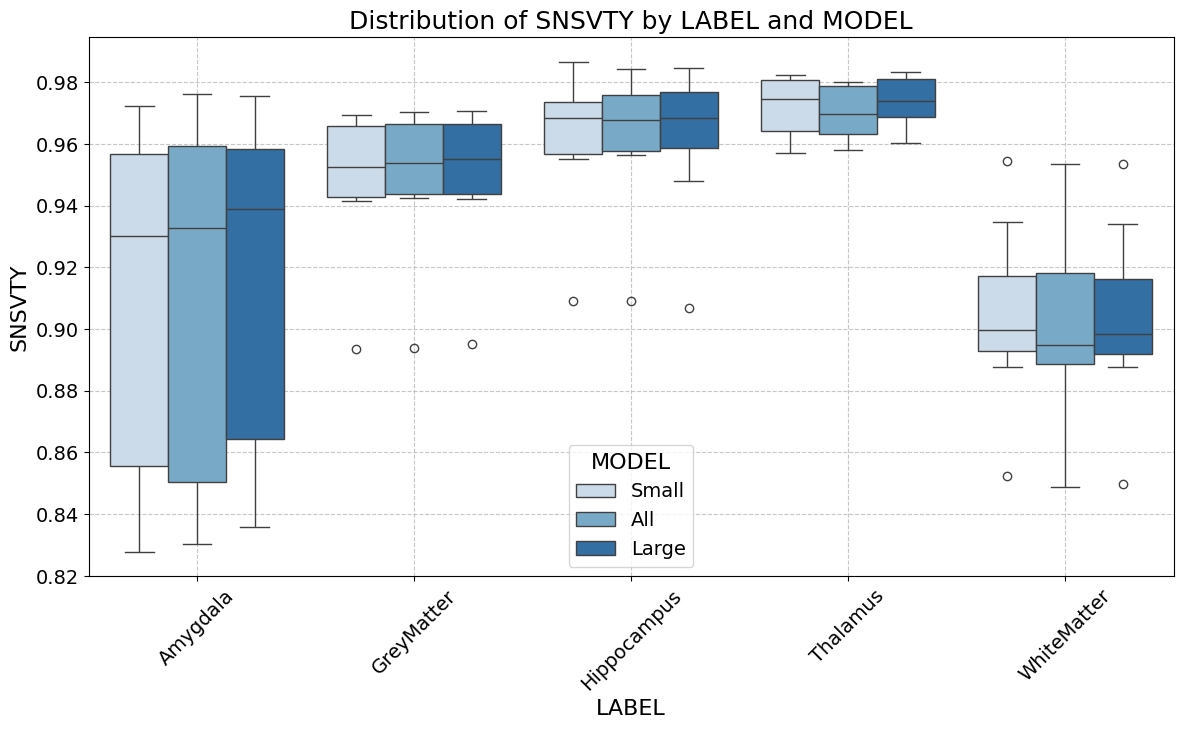

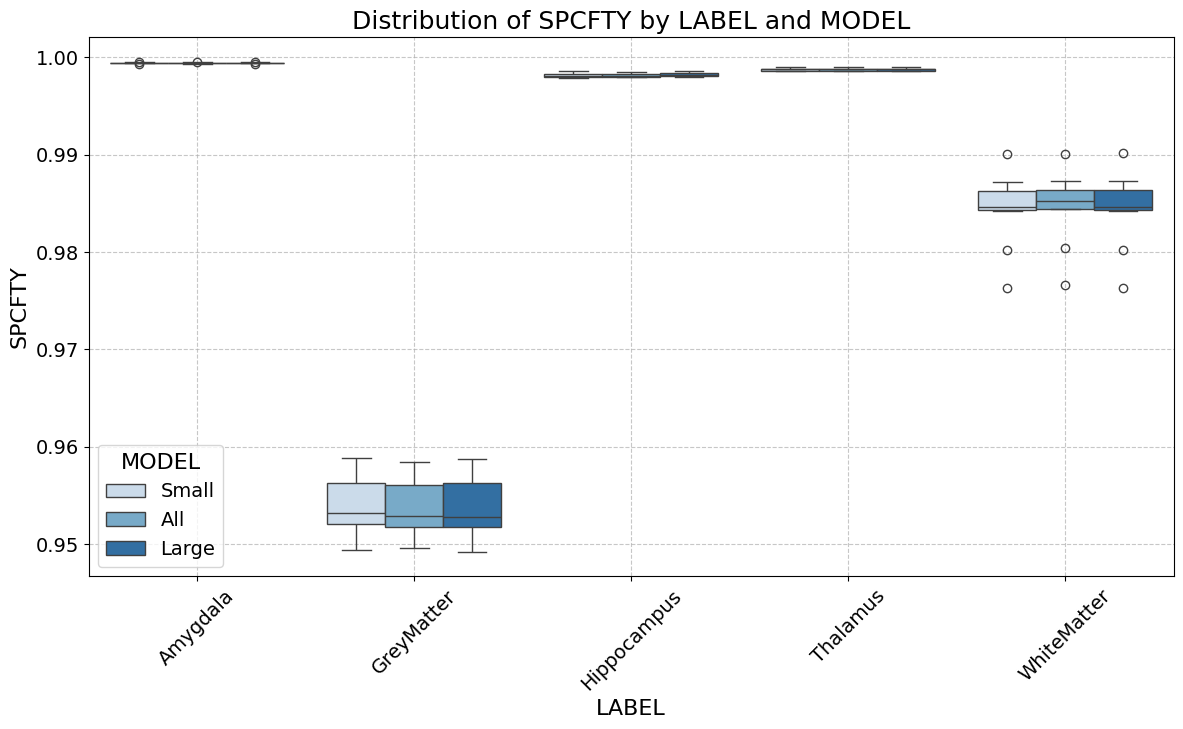

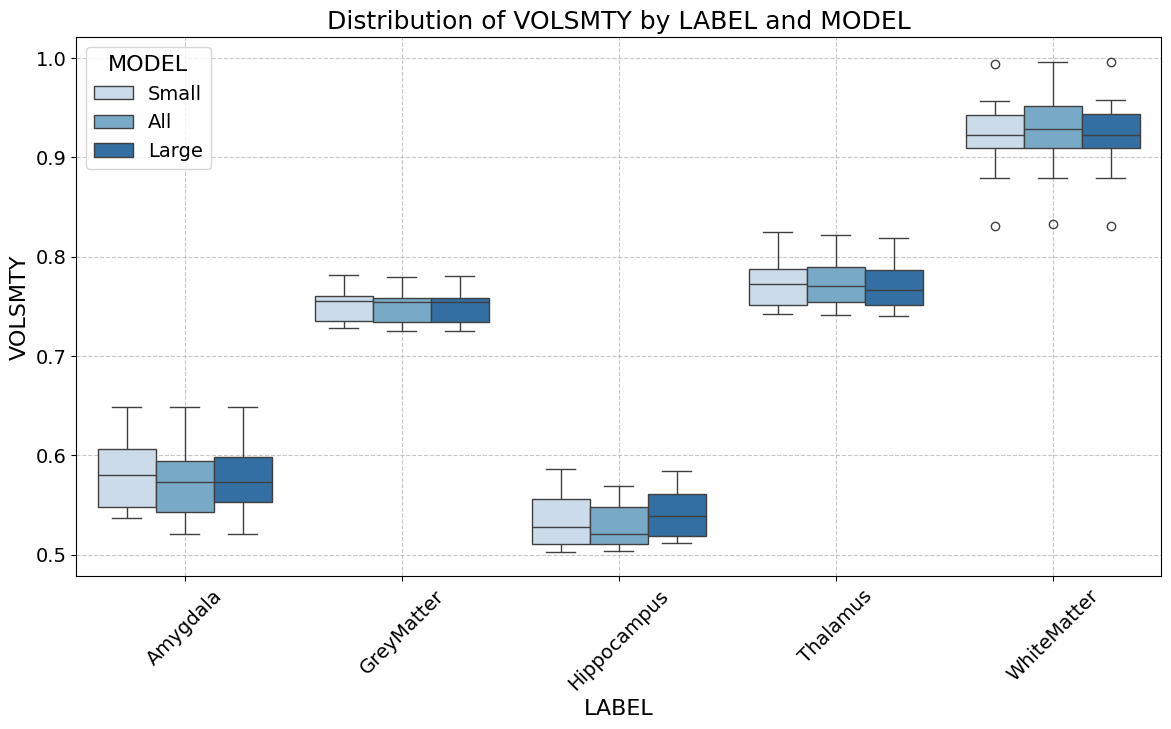

In [15]:
# Add a MODEL column to each dataset
data_small_pp['MODEL'] = 'Small'
data_all_pp['MODEL'] = 'All'
data_large_pp['MODEL'] = 'Large'

# Concatenate all datasets
data_combined = pd.concat([data_small_pp, data_all_pp, data_large_pp], ignore_index=True)

# Set global font size for all text elements
plt.rcParams.update({
    'font.size': 16,         # Base font size for all elements
    'axes.titlesize': 18,    # Font size for plot titles
    'axes.labelsize': 16,    # Font size for x and y labels
    'xtick.labelsize': 14,   # Font size for x-axis tick labels
    'ytick.labelsize': 14,   # Font size for y-axis tick labels
    'legend.fontsize': 14,   # Font size for legend
    'legend.title_fontsize': 16  # Font size for legend title
})

def plot_metric_distributions(data, metrics):
    """
    Plots boxplots for each metric with models side-by-side for each label.
    """
    for metric in metrics:
        plt.figure(figsize=(14, 7))
        sns.boxplot(
            x='LABEL', 
            y=metric, 
            hue='MODEL',  # Add the 'MODEL' column for distinguishing between models
            data=data,
            palette=sns.color_palette("Blues", n_colors=3)
        )
        plt.title(f"Distribution of {metric} by LABEL and MODEL", fontsize=18)
        plt.xlabel('LABEL', fontsize=16)
        plt.ylabel(metric, fontsize=16)
        plt.xticks(rotation=45, fontsize=14)
        plt.legend(title='MODEL', fontsize=14, title_fontsize=16)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

def plot_violin_plots(data, metrics):
    """
    Plots violin plots for each metric with models side-by-side for each label.
    """
    for metric in metrics:
        plt.figure(figsize=(14, 7))
        sns.violinplot(
            x='LABEL', 
            y=metric, 
            hue='MODEL',  # Add the 'MODEL' column for distinguishing between models
            data=data, 
            split=True,  # Split violin plots for better visual comparison
            inner='quartile',
            palette=sns.color_palette("Blues", n_colors=3)
        )
        plt.title(f"Violin plot of {metric} by LABEL and MODEL", fontsize=18)
        plt.xlabel('LABEL', fontsize=16)
        plt.ylabel(metric, fontsize=16)
        plt.xticks(rotation=45, fontsize=14)
        plt.legend(title='MODEL', fontsize=14, title_fontsize=16)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

plot_metric_distributions(data_combined, metrics=['DICE', 'ADJRIND', 'AUC', 'AVGDIST', 'HDRFDST', 'JACRD', 'MUTINF', 
                                                  'RNDIND', 'SNSVTY', 'SPCFTY', 'VOLSMTY'])
#plot_violin_plots(data_combined, metrics=['DICE'])


In [6]:
# labels = data_all['LABEL'].unique()
# num_labels = len(labels)
# fig, axes = plt.subplots(num_labels, 1, figsize=(20, 20 * num_labels))

# for idx, label in enumerate(labels):
#     label_data = diff_df_normalized[data_all['LABEL'] == label]
#     axes[idx].set_title(f'Difference in Metrics for Label: {label}', fontsize=16)
#     for i, metric in enumerate(metrics_columns):
#         sns.boxplot(data=label_data[[f'{metric}_diff_small', f'{metric}_diff_large']], ax=axes[idx])
#         axes[idx].set_xlabel('Model Comparison', fontsize=14)
#         axes[idx].set_ylabel(f'{metric} Difference', fontsize=14)
#         axes[idx].tick_params(axis='x', rotation=45)
#         axes[idx].grid(True, linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.show()

# 2. Per-label performance comparison across models:

In [17]:
def calculate_mean_differences_per_label(grouped_diff, labels):
    mean_differences_per_label = {label: {} for label in labels}
    for label in labels:
        for category, df in grouped_diff.items():
            label_df = df[df['LABEL'] == label]
            mean_differences_per_label[label][category] = {}
            for col in label_df.columns:
                if col not in ['LABEL', 'SUBJECT']:
                    if 'relative' in col:
                        mean_differences_per_label[label][category][col] = label_df[col].mean() * 100  # Convert to percentage
                    else:
                        mean_differences_per_label[label][category][col] = label_df[col].mean()
    return mean_differences_per_label
# Get unique labels
labels = data_all['LABEL'].unique()


mean_diff_small_per_label = calculate_mean_differences_per_label(grouped_diff_small, labels)
mean_diff_large_per_label = calculate_mean_differences_per_label(grouped_diff_large, labels)


In [8]:
# Function to display results in a table format
def display_results(mean_diff_per_label, model_size):
    for category in metrics_categories.keys():
        print(f"\nMean Absolute Differences and Relative Differences for {model_size} Structures Optimised model (Category: {category}):")
        # Create a DataFrame for the current category
        metrics = list(mean_diff_per_label[labels[0]][category].keys())
        df = pd.DataFrame(index=metrics, columns=labels)
        
        # Populate the DataFrame
        for label in labels:
            for metric, value in mean_diff_per_label[label][category].items():
                if 'relative' in metric:
                    df.at[metric, label] = f"{value:.2f}%"
                else:
                    df.at[metric, label] = f"{value}"
        
        # Calculate the mean over the labels for each metric
        mean_values = []
        for metric in metrics:
            values = [float(df.at[metric, label].replace('%', '')) for label in labels if df.at[metric, label] != '']
            mean_value = sum(values) / len(values)
            if 'relative' in metric:
                mean_values.append(f"{mean_value:.2f}%")
            else:
                mean_values.append(f"{mean_value:.2f}")
        
        # Add the mean values as a new column
        df['Mean score over the labels'] = mean_values
        
        # Print the DataFrame
        display(df)
        print()  # Add an empty line for better readability
display_results(mean_diff_small_per_label, 'Small')


Mean Absolute Differences and Relative Differences for Small Structures Optimised model (Category: overlap_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Dice Coefficient_diff_small,0.006966839450870893,0.0006636902589197136,0.004420987168699253,0.0016177092480267996,0.0013766987246849106,0.00
Dice Coefficient_relative_diff_small,1.42%,0.09%,0.84%,0.22%,0.17%,0.55%
Jaccard Index_diff_small,0.006223360356522429,0.0007938702969780054,0.0041031389070702255,0.0020394383449403807,0.002011823228629106,0.00
Jaccard Index_relative_diff_small,1.90%,0.15%,1.15%,0.35%,0.29%,0.77%
Sensitivity_diff_small,-0.002039435170690984,-0.0009520779724939366,6.883775937508441e-05,0.0018826243540819854,0.004706606729028684,0.00
Sensitivity_relative_diff_small,-0.20%,-0.10%,0.01%,0.19%,0.55%,0.09%
Specificity_diff_small,2.0525880336830225e-05,0.0002677864787859474,3.117856717028688e-05,4.792710728640514e-06,-0.00019122826279631687,0.00
Specificity_relative_diff_small,0.00%,0.03%,0.00%,0.00%,-0.02%,0.00%




Mean Absolute Differences and Relative Differences for Small Structures Optimised model (Category: volume_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Volume Similarity_diff_small,0.00909883825215293,0.001458103589238191,0.00459585209694986,0.0002060299426193346,-0.0034650256784785837,0.00
Volume Similarity_relative_diff_small,1.61%,0.19%,0.84%,0.03%,-0.37%,0.46%




Mean Absolute Differences and Relative Differences for Small Structures Optimised model (Category: pair_based):


...

,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Area Under Curve_diff_small,-0.0010094546451771325,-0.00034214574685396124,5.000816327270785e-05,0.000943708532405374,0.0022576892331162,0.00
Area Under Curve_relative_diff_small,-0.10%,-0.04%,0.01%,0.10%,0.25%,0.04%




Mean Absolute Differences and Relative Differences for Small Structures Optimised model (Category: distance_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Average Distance_diff_small,-0.08618611670173346,-1.4176284052042077e-05,-0.07259545754632266,-0.008196463500021045,-0.05180664822986238,-0.04
Average Distance_relative_diff_small,-6.69%,-0.01%,-5.86%,-1.69%,-4.87%,-3.82%
Hausdorff Distance_diff_small,-0.004733989854532617,-0.10800946288521018,-0.271780287384858,-0.1752190436749787,-2.254910368883864,-0.56
Hausdorff Distance_relative_diff_small,0.10%,-0.62%,-1.43%,-1.18%,-1.72%,-0.97%




Mean Absolute Differences and Relative Differences for Small Structures Optimised model (Category: confusion_matrix_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
False Negatives_diff_small,7.2,502.8,-0.3,-33.5,-2328.3,-370.42
False Negatives_relative_diff_small,8.27%,2.14%,-0.47%,-7.46%,-3.14%,-0.13%
False Positives_diff_small,-178.0,-2184.1,-270.2,-41.5,1566.4,-221.48
False Positives_relative_diff_small,-3.27%,-0.59%,-1.77%,-0.39%,1.24%,-0.96%
True Negatives_diff_small,178.0,2184.1,270.2,41.5,-1566.4,221.48
True Negatives_relative_diff_small,0.00%,0.03%,0.00%,0.00%,-0.02%,0.00%
True Positives_diff_small,-7.2,-502.8,0.3,33.5,2328.3,370.42
True Positives_relative_diff_small,-0.20%,-0.10%,0.01%,0.19%,0.55%,0.09%


In [9]:
display_results(mean_diff_small_per_label, 'Large')


Mean Absolute Differences and Relative Differences for Large Structures Optimised model (Category: overlap_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Dice Coefficient_diff_small,0.006966839450870893,0.0006636902589197136,0.004420987168699253,0.0016177092480267996,0.0013766987246849106,0.00
Dice Coefficient_relative_diff_small,1.42%,0.09%,0.84%,0.22%,0.17%,0.55%
Jaccard Index_diff_small,0.006223360356522429,0.0007938702969780054,0.0041031389070702255,0.0020394383449403807,0.002011823228629106,0.00
Jaccard Index_relative_diff_small,1.90%,0.15%,1.15%,0.35%,0.29%,0.77%
Sensitivity_diff_small,-0.002039435170690984,-0.0009520779724939366,6.883775937508441e-05,0.0018826243540819854,0.004706606729028684,0.00
Sensitivity_relative_diff_small,-0.20%,-0.10%,0.01%,0.19%,0.55%,0.09%
Specificity_diff_small,2.0525880336830225e-05,0.0002677864787859474,3.117856717028688e-05,4.792710728640514e-06,-0.00019122826279631687,0.00
Specificity_relative_diff_small,0.00%,0.03%,0.00%,0.00%,-0.02%,0.00%




Mean Absolute Differences and Relative Differences for Large Structures Optimised model (Category: volume_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Volume Similarity_diff_small,0.00909883825215293,0.001458103589238191,0.00459585209694986,0.0002060299426193346,-0.0034650256784785837,0.00
Volume Similarity_relative_diff_small,1.61%,0.19%,0.84%,0.03%,-0.37%,0.46%




Mean Absolute Differences and Relative Differences for Large Structures Optimised model (Category: pair_based):


...

,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Area Under Curve_diff_small,-0.0010094546451771325,-0.00034214574685396124,5.000816327270785e-05,0.000943708532405374,0.0022576892331162,0.00
Area Under Curve_relative_diff_small,-0.10%,-0.04%,0.01%,0.10%,0.25%,0.04%




Mean Absolute Differences and Relative Differences for Large Structures Optimised model (Category: distance_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Average Distance_diff_small,-0.08618611670173346,-1.4176284052042077e-05,-0.07259545754632266,-0.008196463500021045,-0.05180664822986238,-0.04
Average Distance_relative_diff_small,-6.69%,-0.01%,-5.86%,-1.69%,-4.87%,-3.82%
Hausdorff Distance_diff_small,-0.004733989854532617,-0.10800946288521018,-0.271780287384858,-0.1752190436749787,-2.254910368883864,-0.56
Hausdorff Distance_relative_diff_small,0.10%,-0.62%,-1.43%,-1.18%,-1.72%,-0.97%




Mean Absolute Differences and Relative Differences for Large Structures Optimised model (Category: confusion_matrix_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
False Negatives_diff_small,7.2,502.8,-0.3,-33.5,-2328.3,-370.42
False Negatives_relative_diff_small,8.27%,2.14%,-0.47%,-7.46%,-3.14%,-0.13%
False Positives_diff_small,-178.0,-2184.1,-270.2,-41.5,1566.4,-221.48
False Positives_relative_diff_small,-3.27%,-0.59%,-1.77%,-0.39%,1.24%,-0.96%
True Negatives_diff_small,178.0,2184.1,270.2,41.5,-1566.4,221.48
True Negatives_relative_diff_small,0.00%,0.03%,0.00%,0.00%,-0.02%,0.00%
True Positives_diff_small,-7.2,-502.8,0.3,33.5,2328.3,370.42
True Positives_relative_diff_small,-0.20%,-0.10%,0.01%,0.19%,0.55%,0.09%


In [ ]:
def get_metric_category(metric, metrics_categories):
    """
    Returns the category (e.g., 'overlap_based') for a given metric.
    """
    for category, metrics in metrics_categories.items():
        if metric in metrics:
            return category
    raise ValueError(f"Metric '{metric}' not found in any category.")


The category for 'Dice Coefficient' is 'overlap_based'.


In [37]:

def display_metric_comparison(mean_diff_per_label_small, mean_diff_per_label_large, labels, metrics, metrics_dict):
    """
    Displays a table showing the relative difference of specified metrics
    for Small vs. All and Large vs. All models for each label, including the metric name.
    """
    # Initialize an empty list to store results for all metrics
    all_metrics_data = []

    # Iterate through each metric
    for metric in metrics:
        # Initialize a DataFrame for this metric's comparisons
        df = pd.DataFrame(columns=labels, index=["Small vs. All", "Large vs. All"])
        
        # Populate the DataFrame with relative differences for each label
        for label in labels:
            category = get_metric_category(metrics_dict[metric], metrics_categories)
            small_vs_all = mean_diff_per_label_small[label][category][f"{metrics_dict[metric]}_relative_diff_small"]
            large_vs_all = mean_diff_per_label_large[label][category][f"{metrics_dict[metric]}_relative_diff_large"]
            
            # Populate the DataFrame
            df.at["Small vs. All", label] = f"{small_vs_all:.2f}%"
            df.at["Large vs. All", label] = f"{large_vs_all:.2f}%"
        
        # Add a mean row for overall comparison
        df['Mean over labels'] = df.apply(lambda row: 
                                        f"{sum([float(value.replace('%', '')) for value in row if value]) / len(labels):.2f}%", axis=1)
        
        # Add the metric name as a new column
        df.insert(0, 'Metric', metrics_dict[metric])
        
        # Append this metric's DataFrame to the list
        all_metrics_data.append(df)
    
    # Concatenate all metric DataFrames
    final_table = pd.concat(all_metrics_data)
    
    # Display the final table
    display(final_table)
    print()  # Add spacing for readability

labels = ['Amygdala', 'Thalamus', 'Hippocampus', 'GreyMatter', 'WhiteMatter']  
metrics = ['DICE', 'ADJRIND', 'AUC', 'AVGDIST', 'HDRFDST', 'JACRD', 'MUTINF', 'RNDIND', 'SNSVTY', 'SPCFTY', 'VOLSMTY']

display_metric_comparison(mean_diff_small_per_label, mean_diff_large_per_label, labels, metrics, metrics_dict)


,Metric,Amygdala,Thalamus,Hippocampus,GreyMatter,WhiteMatter,Mean over labels
Small vs. All,Dice Coefficient,1.42%,0.22%,0.84%,0.09%,0.17%,0.55%
Large vs. All,Dice Coefficient,1.50%,-0.03%,2.21%,0.04%,0.10%,0.76%
Small vs. All,Adjusted Rand Index,1.42%,0.22%,0.85%,0.14%,0.19%,0.56%
Large vs. All,Adjusted Rand Index,1.51%,-0.03%,2.23%,0.05%,0.11%,0.77%
Small vs. All,Area Under Curve,-0.10%,0.10%,0.01%,-0.04%,0.25%,0.04%
Large vs. All,Area Under Curve,0.33%,0.16%,-0.01%,0.02%,0.19%,0.14%
Small vs. All,Average Distance,-6.69%,-1.69%,-5.86%,-0.01%,-4.87%,-3.82%
Large vs. All,Average Distance,-8.69%,-1.50%,-7.04%,-1.60%,-4.11%,-4.59%
Small vs. All,Hausdorff Distance,0.10%,-1.18%,-1.43%,-0.62%,-1.72%,-0.97%
Large vs. All,Hausdorff Distance,-2.36%,-0.44%,1.14%,-11.97%,-4.57%,-3.64%


# 3. Trend analysis across metric categories:

is the same as looking just per categorie at the mean differences

In [10]:
def calculate_mean_category_differences_per_label(grouped_diff, labels):
    mean_differences_per_label = {label: {} for label in labels}
    overall_mean_differences = {label: {} for label in labels}
    
    for label in labels:
        for category, df in grouped_diff.items():
            label_df = df[df['LABEL'] == label]
            mean_differences_per_label[label][category] = {}
            for col in label_df.columns:
                if col not in ['LABEL', 'SUBJECT']:
                    if 'relative' in col:
                        mean_value = label_df[col].mean() * 100  # Convert to percentage
                        mean_differences_per_label[label][category][col] = mean_value
                        if category not in overall_mean_differences[label]:
                            overall_mean_differences[label][category] = []
                        overall_mean_differences[label][category].append(mean_value)
    
    # Calculate the overall mean relative differences for each category per label
    for label, categories in overall_mean_differences.items():
        for category, values in categories.items():
            overall_mean_differences[label][category] = sum(values) / len(values)
    
    return mean_differences_per_label, overall_mean_differences

# Get unique labels
labels = data_all['LABEL'].unique()

mean_diff_small_per_label, overall_mean_diff_small = calculate_mean_category_differences_per_label(grouped_diff_small, labels)
mean_diff_large_per_label, overall_mean_diff_large = calculate_mean_category_differences_per_label(grouped_diff_large, labels)

In [11]:
# Function to display results in a table format
def display_results(mean_diff_per_label, overall_mean_diff, model_size):
    for category in metrics_categories.keys():
        print(f"\nMean Relative Differences for {model_size} Optimised model (Category: {category}):")
        # Create a DataFrame for the current category
        metrics = list(mean_diff_per_label[labels[0]][category].keys())
        df = pd.DataFrame(index=metrics, columns=labels)
        
        # Populate the DataFrame with mean differences per label
        for label in labels:
            for metric, value in mean_diff_per_label[label][category].items():
                df.at[metric, label] = f"{value:.3f}%"
        
        # Add a row for the overall mean differences
        overall_means = []
        for label in labels:
            if label in overall_mean_diff and category in overall_mean_diff[label]:
                overall_means.append(f"{overall_mean_diff[label][category]:.3f}%")
            else:
                overall_means.append("N/A")
        df.loc['Overall Mean'] = overall_means
        # Calculate the mean over the labels for each metric
        mean_values = []
        for metric in metrics + ['Overall Mean']:
            values = [float(df.at[metric, label].replace('%', '')) for label in labels  if df.at[metric, label] != '']
            mean_value = sum(values) / len(values)
            if 'relative' or 'Mean' in metric:
                mean_values.append(f"{mean_value:.2f}%")
            else:
                mean_values.append(f"{mean_value:.2f}")
        
        # Add the mean values as a new column
        df['Mean score over the labels'] = mean_values
        # Print the DataFrame
        display(df)
        print()  # Add an empty line for better readability

# Display results for small and large models
display_results(mean_diff_small_per_label, overall_mean_diff_small, 'Small')


Mean Relative Differences for Small Optimised model (Category: overlap_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Dice Coefficient_relative_diff_small,1.417%,0.094%,0.844%,0.220%,0.169%,0.55%
Jaccard Index_relative_diff_small,1.897%,0.145%,1.154%,0.349%,0.293%,0.77%
Sensitivity_relative_diff_small,-0.195%,-0.100%,0.007%,0.193%,0.552%,0.09%
Specificity_relative_diff_small,0.002%,0.028%,0.003%,0.000%,-0.019%,0.00%
Overall Mean,0.780%,0.042%,0.502%,0.191%,0.249%,0.35%




Mean Relative Differences for Small Optimised model (Category: volume_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Volume Similarity_relative_diff_small,1.613%,0.194%,0.837%,0.026%,-0.367%,0.46%
Overall Mean,1.613%,0.194%,0.837%,0.026%,-0.367%,0.46%




Mean Relative Differences for Small Optimised model (Category: pair_based):


...

,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Area Under Curve_relative_diff_small,-0.099%,-0.036%,0.005%,0.096%,0.246%,0.04%
Overall Mean,-0.099%,-0.036%,0.005%,0.096%,0.246%,0.04%




Mean Relative Differences for Small Optimised model (Category: distance_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
Average Distance_relative_diff_small,-6.689%,-0.007%,-5.856%,-1.695%,-4.870%,-3.82%
Hausdorff Distance_relative_diff_small,0.101%,-0.617%,-1.429%,-1.180%,-1.721%,-0.97%
Overall Mean,-3.294%,-0.312%,-3.643%,-1.438%,-3.296%,-2.40%




Mean Relative Differences for Small Optimised model (Category: confusion_matrix_based):


,Amygdala,GreyMatter,Hippocampus,Thalamus,WhiteMatter,Mean score over the labels
False Negatives_relative_diff_small,8.268%,2.137%,-0.468%,-7.457%,-3.139%,-0.13%
False Positives_relative_diff_small,-3.266%,-0.585%,-1.770%,-0.392%,1.236%,-0.96%
True Negatives_relative_diff_small,0.002%,0.028%,0.003%,0.000%,-0.019%,0.00%
True Positives_relative_diff_small,-0.195%,-0.100%,0.007%,0.193%,0.552%,0.09%
Overall Mean,1.202%,0.370%,-0.557%,-1.914%,-0.343%,-0.25%


In [38]:
def aggregate_category_influence(mean_diff_per_label_small, mean_diff_per_label_large, metrics_categories, labels):
    """
    Aggregates the relative differences for all metrics within each category.
    """
    category_diffs = {'Small vs. All': {}, 'Large vs. All': {}}
    
    for category, metrics in metrics_categories.items():
        small_diffs = []
        large_diffs = []
        
        for metric in metrics:
            for label in labels:
                # Get the relative differences for the current metric
                key_small = f"{metric}_relative_diff_small"
                key_large = f"{metric}_relative_diff_large"
                
                # Check if metric exists in the category (skip missing metrics)
                if key_small in mean_diff_per_label_small[label][category]:
                    small_diffs.append(mean_diff_per_label_small[label][category][key_small])
                if key_large in mean_diff_per_label_large[label][category]:
                    large_diffs.append(mean_diff_per_label_large[label][category][key_large])
        
        # Calculate mean relative difference for the category
        category_diffs['Small vs. All'][category] = sum(small_diffs) / len(small_diffs) if small_diffs else 0
        category_diffs['Large vs. All'][category] = sum(large_diffs) / len(large_diffs) if large_diffs else 0
    
    return category_diffs

# Example usage
categories_diffs = aggregate_category_influence(mean_diff_small_per_label, mean_diff_large_per_label, metrics_categories, labels)
print(categories_diffs)


{'Small vs. All': {'overlap_based': np.float64(0.3526116285192131), 'volume_based': np.float64(0.4610169681137812), 'pair_based': np.float64(0.28824109329758996), 'information_based': np.float64(0.2709314401731743), 'probability_based': np.float64(0.04227798864670978), 'distance_based': np.float64(-2.3964010783661007), 'confusion_matrix_based': np.float64(-0.24832934071325238)}, 'Large vs. All': {'overlap_based': np.float64(0.5273514073545228), 'volume_based': np.float64(0.4742189500948176), 'pair_based': np.float64(0.3910263974083081), 'information_based': np.float64(0.5652764194439871), 'probability_based': np.float64(0.13855901992020453), 'distance_based': np.float64(-4.11478666249526), 'confusion_matrix_based': np.float64(-1.0945366602071342)}}


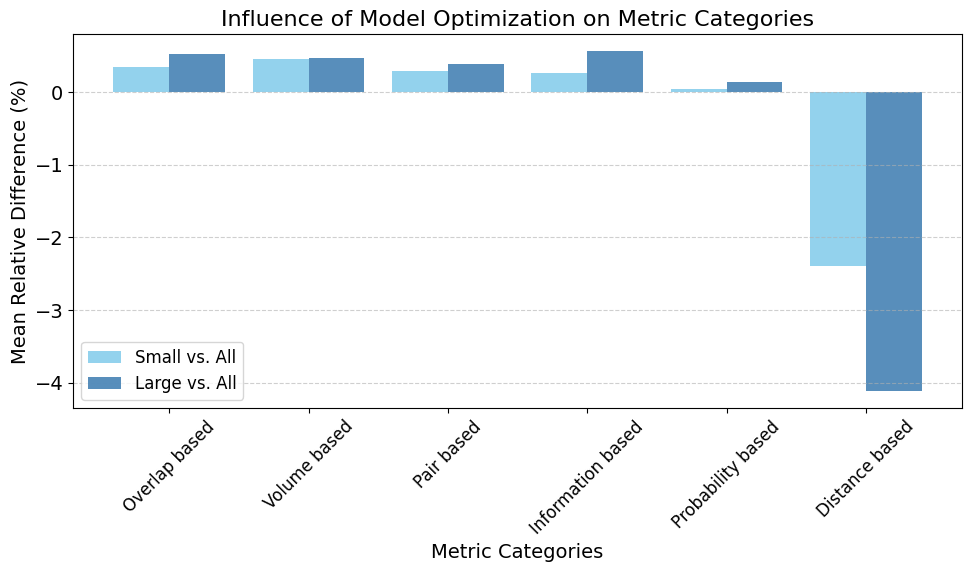

In [44]:
def plot_category_influence(category_diffs):
    """
    Visualizes the influence of models on metric categories with blue bars and formatted x-axis labels.
    """
    # Extract categories and values
    categories = list(category_diffs['Small vs. All'].keys())[:-1]
    formatted_categories = [cat.replace('_', ' ').capitalize() for cat in categories]  # Format x-axis labels
    small_vs_all = [category_diffs['Small vs. All'][cat] for cat in categories]
    large_vs_all = [category_diffs['Large vs. All'][cat] for cat in categories]

    x = range(len(categories))

    plt.figure(figsize=(10, 6))
    plt.bar(x, small_vs_all, width=0.4, label='Small vs. All', align='center', color='skyblue', alpha=0.9)
    plt.bar([p + 0.4 for p in x], large_vs_all, width=0.4, label='Large vs. All', align='center', color='steelblue', alpha=0.9)
    plt.xticks([p + 0.2 for p in x], formatted_categories, rotation=45, fontsize=12)
    plt.xlabel("Metric Categories", fontsize=14)
    plt.ylabel("Mean Relative Difference (%)", fontsize=14)
    plt.title("Influence of Model Optimization on Metric Categories", fontsize=16)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# Example usage
plot_category_influence(categories_diffs)



Maybe it is better to focus only on the improvement for large structures for the model optimized on large and same for small?

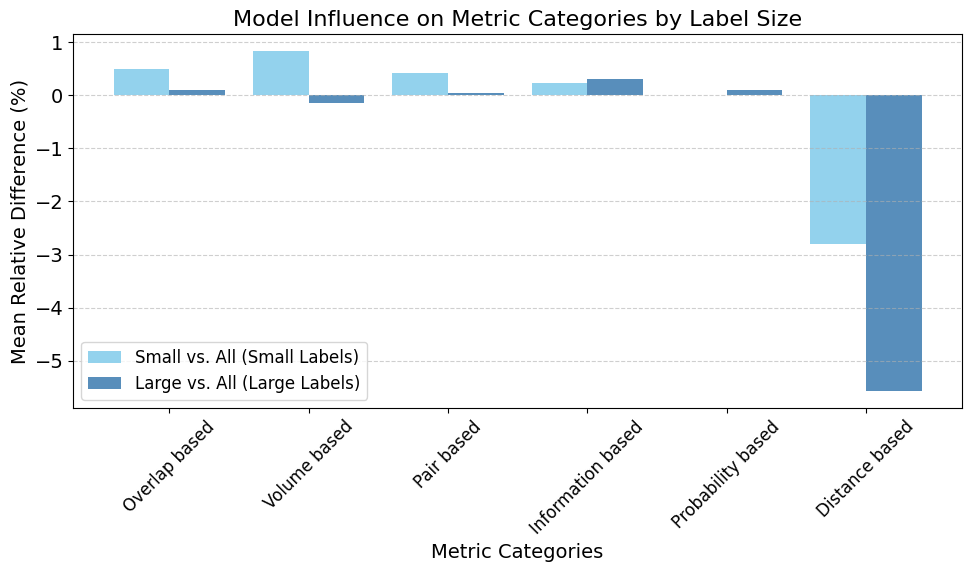

In [48]:
def calculate_label_specific_differences(mean_diff_per_label_small, mean_diff_per_label_large, small_labels, large_labels, metrics_categories):
    """
    Calculates mean relative differences for small labels with 'Small vs. All'
    and large labels with 'Large vs. All' across metric categories.
    """
    category_diffs = {'Small vs. All (Small Labels)': {}, 'Large vs. All (Large Labels)': {}}

    for category, metrics in metrics_categories.items():
        small_diffs = []
        large_diffs = []
        
        # Collect relative differences for small labels
        for label in small_labels:
            for metric in metrics:
                key_small = f"{metric}_relative_diff_small"
                if key_small in mean_diff_per_label_small[label][category]:
                    small_diffs.append(mean_diff_per_label_small[label][category][key_small])
        
        # Collect relative differences for large labels
        for label in large_labels:
            for metric in metrics:
                key_large = f"{metric}_relative_diff_large"
                if key_large in mean_diff_per_label_large[label][category]:
                    large_diffs.append(mean_diff_per_label_large[label][category][key_large])
        
        # Calculate mean relative differences for each category
        category_diffs['Small vs. All (Small Labels)'][category] = sum(small_diffs) / len(small_diffs) if small_diffs else 0
        category_diffs['Large vs. All (Large Labels)'][category] = sum(large_diffs) / len(large_diffs) if large_diffs else 0
    
    return category_diffs

def plot_label_specific_category_influence(category_diffs):
    """
    Visualizes the influence of models on metric categories for small and large labels.
    """
    categories = list(category_diffs['Small vs. All (Small Labels)'].keys())[:-1]
    formatted_categories = [cat.replace('_', ' ').capitalize() for cat in categories]
    small_vs_all = [category_diffs['Small vs. All (Small Labels)'][cat] for cat in categories]
    large_vs_all = [category_diffs['Large vs. All (Large Labels)'][cat] for cat in categories]

    x = range(len(categories))

    plt.figure(figsize=(10, 6))
    plt.bar(x, small_vs_all, width=0.4, label='Small vs. All (Small Labels)', align='center', color='skyblue', alpha=0.9)
    plt.bar([p + 0.4 for p in x], large_vs_all, width=0.4, label='Large vs. All (Large Labels)', align='center', color='steelblue', alpha=0.9)
    plt.xticks([p + 0.2 for p in x], formatted_categories, rotation=45, fontsize=12)
    plt.xlabel("Metric Categories", fontsize=14)
    plt.ylabel("Mean Relative Difference (%)", fontsize=14)
    plt.title("Model Influence on Metric Categories by Label Size", fontsize=16)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# Example Usage
small_labels = ['Hippocampus', 'Amygdala', 'Thalamus']
large_labels = ['GreyMatter', 'WhiteMatter']

categories_diffs = calculate_label_specific_differences(mean_diff_small_per_label, mean_diff_large_per_label, small_labels, large_labels, metrics_categories)
plot_label_specific_category_influence(categories_diffs)


# 4. Statistical significance of per-metric differences per label:

In [ ]:
# Define the metrics columns to be tested
metrics_columns = ['ADJRIND', 'AUC', 'AVGDIST', 'DICE', 'FN', 'FP', 'HDRFDST', 'JACRD', 'MUTINF', 'PRCISON', 'RNDIND', 'SNSVTY', 'SPCFTY', 'TN', 'TP', 'VOLSMTY']

In [ ]:
# first test for normality to see if t test can be executed
from scipy.stats import shapiro
# Function to test normality of metric differences
def test_normality(data_all, data_spec, metrics_columns, labels):
    normality_results = {}
    
    for label in labels:
        normality_results[label] = {}
        data_all_label = data_all[data_all['LABEL'] == label]
        data_spec_label = data_spec[data_spec['LABEL'] == label]
        
        for metric in metrics_columns:
            all_values = data_all_label[metric].values
            spec_values = data_spec_label[metric].values
            # Compute differences
            differences = spec_values - all_values
            # Perform Shapiro-Wilk test
            stat, p_val = shapiro(differences)
            # Check if p-value indicates non-normality
            normal = p_val >= 0.05
            
            normality_results[label][metric] = {
                'shapiro_stat': stat,
                'p_val': p_val,
                'Normal': normal}
    return normality_results

# Test for normality
normality_results = test_normality(data_all, data_small, metrics_columns, labels)
normality_results_l = test_normality(data_all, data_large, metrics_columns, labels)

# Display normality test results
def display_normality_results(normality_results):
    for label, metrics in normality_results.items():
        print(f"\nNormality Test Results for Label: {label}")
        df = pd.DataFrame(metrics).T
        df['Normal'] = df['Normal'].map({True: 'Yes', False: 'No'})
        display(df)
print('SMALL')
display_normality_results(normality_results)
print('-------------------------------------------------')
print('LARGE')
display_normality_results(normality_results_l)

SMALL

Normality Test Results for Label: Amygdala


,shapiro_stat,p_val,Normal
ADJRIND,0.909189,0.061508,Yes
AUC,0.875085,0.014451,No
AVGDIST,0.931935,0.168228,Yes
DICE,0.909077,0.061207,Yes
FN,0.864953,0.009591,No
FP,0.957358,0.492516,Yes
HDRFDST,0.704281,0.000044,No
JACRD,0.911955,0.06945,Yes
MUTINF,0.91293,0.072495,Yes
PRCISON,0.935706,0.198686,Yes



Normality Test Results for Label: GreyMatter


,shapiro_stat,p_val,Normal
ADJRIND,0.929378,0.150218,Yes
AUC,0.907658,0.05752,Yes
AVGDIST,0.70938,0.000051,No
DICE,0.92861,0.145189,Yes
FN,0.918175,0.091392,Yes
FP,0.906075,0.05368,Yes
HDRFDST,0.962789,0.600943,Yes
JACRD,0.930539,0.158152,Yes
MUTINF,0.84258,0.004013,No
PRCISON,0.924981,0.123592,Yes



Normality Test Results for Label: Hippocampus


...

,shapiro_stat,p_val,Normal
ADJRIND,0.974083,0.837629,Yes
AUC,0.677866,0.000021,No
AVGDIST,0.958644,0.517131,Yes
DICE,0.974098,0.83792,Yes
FN,0.687627,0.000028,No
FP,0.951989,0.39829,Yes
HDRFDST,0.777973,0.000413,No
JACRD,0.977862,0.903606,Yes
MUTINF,0.796741,0.000773,No
PRCISON,0.974094,0.837845,Yes



Normality Test Results for Label: Thalamus


,shapiro_stat,p_val,Normal
ADJRIND,0.94268,0.269302,Yes
AUC,0.826453,0.002203,No
AVGDIST,0.97574,0.868198,Yes
DICE,0.942536,0.26764,Yes
FN,0.812687,0.001344,No
FP,0.967827,0.708489,Yes
HDRFDST,0.765131,0.000273,No
JACRD,0.944277,0.288426,Yes
MUTINF,0.861925,0.0085,No
PRCISON,0.964448,0.635979,Yes



Normality Test Results for Label: WhiteMatter


,shapiro_stat,p_val,Normal
ADJRIND,0.405147,0.0,No
AUC,0.32129,0.0,No
AVGDIST,0.257986,0.0,No
DICE,0.395303,0.0,No
FN,0.31934,0.0,No
FP,0.750019,0.00017,No
HDRFDST,0.424536,0.0,No
JACRD,0.394345,0.0,No
MUTINF,0.336578,0.0,No
PRCISON,0.924825,0.122737,Yes


In [67]:
from scipy.stats import ttest_rel
import pandas as pd
import numpy as np

# Function to compute Cohen's d for paired samples
def cohen_d_paired(x, y):
    diff = x - y
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)  # Use sample standard deviation
    return mean_diff / std_diff if std_diff != 0 else np.nan

# Function to perform paired t-tests and check for statistical significance
def check_statistical_significance(data_all, data_spec, metrics_columns, labels):
    results = {}
    for label in labels:
        results[label] = {}
        data_all_label = data_all[data_all['LABEL'] == label]
        data_spec_label = data_spec[data_spec['LABEL'] == label]
        
        for metric in metrics_columns:
            all_values = data_all_label[metric].values
            spec_values = data_spec_label[metric].values
            
            # Perform paired t-test
            t_stat, p_val = ttest_rel(spec_values, all_values, ) #paired t test!
            # Compute effect size (Cohen's d for paired samples)
            effect_size = cohen_d_paired(spec_values, all_values, )
            # Check if the p-value is less than 0.05 (statistical significance)
            significant = p_val < 0.05
            results[label][metric] = {'t_stat': t_stat,'p_val': p_val,'significant': significant,'effect_size': effect_size}
    return results

significance_results = check_statistical_significance(data_all, data_small, metrics_columns, labels)
significance_results_l = check_statistical_significance(data_all, data_large, metrics_columns, labels)

# Function to display the results, including effect size
def display_significance_results(significance_results):
    for label, metrics in significance_results.items():
        print(f"\nStatistical Significance for Label: {label}")
        df = pd.DataFrame(metrics).T
        df['significant'] = df['significant'].map({True: 'Yes', False: 'No'})
        display(df)

# Display the results with effect sizes
print('SMALL')
display_significance_results(significance_results)
print('-------------------------------------------------')
print('LARGE')
display_significance_results(significance_results_l)


SMALL

Statistical Significance for Label: Amygdala


,t_stat,p_val,significant,effect_size
ADJRIND,3.898409,0.000966,Yes,0.871711
AUC,-1.358593,0.190188,No,-0.303791
AVGDIST,-8.669494,0.0,Yes,-1.938558
DICE,3.896655,0.00097,Yes,0.871318
FN,1.548362,0.138031,No,0.346224
FP,-5.353149,0.000036,Yes,-1.197
HDRFDST,0.756248,0.458775,No,0.169102
JACRD,3.913793,0.000933,Yes,0.875151
MUTINF,-0.128271,0.899282,No,-0.028682
PRCISON,4.525002,0.000232,Yes,1.011821



Statistical Significance for Label: GreyMatter


,t_stat,p_val,significant,effect_size
ADJRIND,4.664752,0.000169,Yes,1.04307
AUC,-9.604585,0.0,Yes,-2.14765
AVGDIST,-0.579041,0.569364,No,-0.129477
DICE,4.365244,0.000333,Yes,0.976098
FN,12.466376,0.0,Yes,2.787566
FP,-6.977665,0.000001,Yes,-1.560253
HDRFDST,-0.356054,0.725723,No,-0.079616
JACRD,4.395007,0.000311,Yes,0.982754
MUTINF,-2.509167,0.021324,Yes,-0.561067
PRCISON,6.040497,0.000008,Yes,1.350696



Statistical Significance for Label: Hippocampus


...

,t_stat,p_val,significant,effect_size
ADJRIND,10.975119,0.0,Yes,2.454111
AUC,-0.276165,0.785403,No,-0.061752
AVGDIST,-8.006665,0.0,Yes,-1.790345
DICE,10.971327,0.0,Yes,2.453263
FN,0.396126,0.696425,No,0.088577
FP,-11.62372,0.0,Yes,-2.599143
HDRFDST,2.645855,0.015942,Yes,0.591631
JACRD,10.655973,0.0,Yes,2.382748
MUTINF,4.723568,0.000148,Yes,1.056222
PRCISON,11.006002,0.0,Yes,2.461017



Statistical Significance for Label: Thalamus


,t_stat,p_val,significant,effect_size
ADJRIND,-0.59313,0.560089,No,-0.132628
AUC,7.505059,0.0,Yes,1.678182
AVGDIST,-0.652947,0.521614,No,-0.146003
DICE,-0.585428,0.565149,No,-0.130906
FN,-7.715988,0.0,Yes,-1.725347
FP,3.852014,0.001074,Yes,0.861336
HDRFDST,-1.288772,0.212949,No,-0.288178
JACRD,-0.57924,0.569232,No,-0.129522
MUTINF,4.557257,0.000215,Yes,1.019034
PRCISON,-2.356001,0.029365,Yes,-0.526818



Statistical Significance for Label: WhiteMatter


,t_stat,p_val,significant,effect_size
ADJRIND,0.080934,0.936341,No,0.018097
AUC,0.615283,0.545668,No,0.137582
AVGDIST,-0.797559,0.434981,No,-0.17834
DICE,0.122699,0.903634,No,0.027436
FN,-0.664001,0.514667,No,-0.148475
FP,2.378972,0.028002,Yes,0.531954
HDRFDST,-1.364012,0.188505,No,-0.305002
JACRD,0.136267,0.893043,No,0.03047
MUTINF,0.426391,0.674615,No,0.095344
PRCISON,-3.37771,0.00316,Yes,-0.755279


## alternative that performs non-parametric and t tests to see if it

In [ ]:
from scipy.stats import wilcoxon

# Function to compute rank-biserial correlation for Wilcoxon signed-rank test: https://en.wikipedia.org/wiki/Wilcoxon_signed-rank_test#Effect_size
def rank_biserial_correlation(x, y):
    n = len(x)
    diff = x - y
    ranks = np.abs(diff).argsort().argsort() + 1
    w = np.sum(ranks[diff > 0])
    return (2 * w / (n * (n + 1))) - 1

# Function to test normality of metric differences
def test_normality(data_all, data_spec, metrics_columns, labels):
    normality_results = {}
    for label in labels:
        normality_results[label] = {}
        data_all_label = data_all[data_all['LABEL'] == label]
        data_spec_label = data_spec[data_spec['LABEL'] == label]
        
        for metric in metrics_columns:
            all_values = data_all_label[metric].values
            spec_values = data_spec_label[metric].values
            
            # Compute differences
            differences = spec_values - all_values
            
            # Perform Shapiro-Wilk test
            stat, p = shapiro(differences)
            normality_results[label][metric] = p > 0.05  # True if normal distribution can be assumed
    
    return normality_results

# Function to perform paired t-tests or Wilcoxon signed-rank tests based on normality
def check_statistical_significance(data_all, data_spec, metrics_columns, labels, normality_results):
    results = {}
    for label in labels:
        results[label] = {}
        data_all_label = data_all[data_all['LABEL'] == label]
        data_spec_label = data_spec[data_spec['LABEL'] == label]
        
        for metric in metrics_columns:
            all_values = data_all_label[metric].values
            spec_values = data_spec_label[metric].values
  
            if normality_results[label][metric]:
                # Perform paired t-test
                t_stat, p_val = ttest_rel(spec_values, all_values) # t metric is now new model (specific) - old model (general model)
                effect_size = cohen_d_paired(spec_values, all_values)
                test_name = 'Paired t-test'
            else:
                # Perform Wilcoxon signed-rank test
                t_stat, p_val = wilcoxon(spec_values, all_values)
                effect_size = rank_biserial_correlation(spec_values, all_values)
                test_name = 'Wilcoxon signed-rank test'
            significance = p_val < 0.05
            results[label][metric] = {'test': test_name, 't_stat': t_stat, 'p_val': p_val, 'effect_size': effect_size, 'significant': significance}
    return results

# Perform the statistical significance check and apply to get the specific statistical tests
normality_results = test_normality(data_all, data_small, metrics_columns, labels)
statistical_significance_results = check_statistical_significance(data_all, data_small, metrics_columns, labels, normality_results)

normality_results_l = test_normality(data_all, data_large, metrics_columns, labels)
statistical_significance_results_l = check_statistical_significance(data_all, data_large, metrics_columns, labels, normality_results)


print('SMALL RESULTS')
display_significance_results(statistical_significance_results)
print('------------------------------------------')
print('LARGE RESULTS')
display_significance_results(statistical_significance_results_l)

SMALL RESULTS

Statistical Significance for Label: Amygdala


,test,t_stat,p_val,effect_size,significant
ADJRIND,Paired t-test,3.898409,0.000966,0.871711,Yes
AUC,Wilcoxon signed-rank test,66.0,0.153646,-0.685714,No
AVGDIST,Paired t-test,-8.669494,0.0,-1.938558,Yes
DICE,Paired t-test,3.896655,0.00097,0.871318,Yes
FN,Wilcoxon signed-rank test,63.0,0.123093,-0.295238,No
FP,Paired t-test,-5.353149,0.000036,-1.197,Yes
HDRFDST,Wilcoxon signed-rank test,70.0,0.31434,-0.37619,No
JACRD,Paired t-test,3.913793,0.000933,0.875151,Yes
MUTINF,Paired t-test,-0.128271,0.899282,-0.028682,No
PRCISON,Paired t-test,4.525002,0.000232,1.011821,Yes



Statistical Significance for Label: GreyMatter


,test,t_stat,p_val,effect_size,significant
ADJRIND,Paired t-test,4.664752,0.000169,1.04307,Yes
AUC,Paired t-test,-9.604585,0.0,-2.14765,Yes
AVGDIST,Wilcoxon signed-rank test,52.0,0.048441,-0.752381,Yes
DICE,Paired t-test,4.365244,0.000333,0.976098,Yes
FN,Paired t-test,12.466376,0.0,2.787566,Yes
FP,Paired t-test,-6.977665,0.000001,-1.560253,Yes
HDRFDST,Paired t-test,-0.356054,0.725723,-0.079616,No
JACRD,Paired t-test,4.395007,0.000311,0.982754,Yes
MUTINF,Wilcoxon signed-rank test,34.0,0.00639,-0.838095,Yes
PRCISON,Paired t-test,6.040497,0.000008,1.350696,Yes



Statistical Significance for Label: Hippocampus


...

,test,t_stat,p_val,effect_size,significant
ADJRIND,Paired t-test,10.975119,0.0,2.454111,Yes
AUC,Paired t-test,-0.276165,0.785403,-0.061752,No
AVGDIST,Paired t-test,-8.006665,0.0,-1.790345,Yes
DICE,Paired t-test,10.971327,0.0,2.453263,Yes
FN,Paired t-test,0.396126,0.696425,0.088577,No
FP,Paired t-test,-11.62372,0.0,-2.599143,Yes
HDRFDST,Wilcoxon signed-rank test,36.0,0.017571,-0.2,Yes
JACRD,Paired t-test,10.655973,0.0,2.382748,Yes
MUTINF,Wilcoxon signed-rank test,26.0,0.001986,-0.12381,Yes
PRCISON,Paired t-test,11.006002,0.0,2.461017,Yes



Statistical Significance for Label: Thalamus


,test,t_stat,p_val,effect_size,significant
ADJRIND,Paired t-test,-0.59313,0.560089,-0.132628,No
AUC,Paired t-test,7.505059,0.0,1.678182,Yes
AVGDIST,Paired t-test,-0.652947,0.521614,-0.146003,No
DICE,Paired t-test,-0.585428,0.565149,-0.130906,No
FN,Paired t-test,-7.715988,0.0,-1.725347,Yes
FP,Paired t-test,3.852014,0.001074,0.861336,Yes
HDRFDST,Wilcoxon signed-rank test,74.0,0.261099,-0.647619,No
JACRD,Paired t-test,-0.57924,0.569232,-0.129522,No
MUTINF,Paired t-test,4.557257,0.000215,1.019034,Yes
PRCISON,Paired t-test,-2.356001,0.029365,-0.526818,Yes



Statistical Significance for Label: WhiteMatter


,test,t_stat,p_val,effect_size,significant
ADJRIND,Wilcoxon signed-rank test,32.0,0.00486,-0.847619,Yes
AUC,Wilcoxon signed-rank test,43.0,0.019234,-0.795238,Yes
AVGDIST,Wilcoxon signed-rank test,20.0,0.000708,-0.095238,Yes
DICE,Wilcoxon signed-rank test,32.0,0.00486,-0.847619,Yes
FN,Wilcoxon signed-rank test,49.0,0.036234,-0.233333,Yes
FP,Wilcoxon signed-rank test,44.0,0.021484,-0.209524,Yes
HDRFDST,Wilcoxon signed-rank test,50.0,0.122095,-0.67619,No
JACRD,Wilcoxon signed-rank test,32.0,0.00486,-0.847619,Yes
MUTINF,Wilcoxon signed-rank test,35.0,0.007296,-0.833333,Yes
PRCISON,Paired t-test,-3.37771,0.00316,-0.755279,Yes


Integrated code to automatically perform t-test or Wilcoxon depending on result of normal test

In [51]:
from scipy.stats import shapiro, ttest_rel, wilcoxon
import pandas as pd
import numpy as np

# Function to compute Cohen's d for paired samples
def cohen_d_paired(x, y):
    diff = x - y
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)  # Use sample standard deviation
    return mean_diff / std_diff if std_diff != 0 else np.nan

# Function to compute rank-biserial correlation for Wilcoxon signed-rank test
def rank_biserial_correlation(x, y):
    n = len(x)
    diff = x - y
    ranks = np.abs(diff).argsort().argsort() + 1
    w = np.sum(ranks[diff > 0])
    return (2 * w / (n * (n + 1))) - 1

# Integrated function for statistical testing
def perform_statistical_tests(data_all, data_spec, metrics_columns, labels):
    """
    Perform normality tests and apply either paired t-test or Wilcoxon signed-rank test.
    """
    results = {}
    
    for label in labels:
        results[label] = {}
        data_all_label = data_all[data_all['LABEL'] == label]
        data_spec_label = data_spec[data_spec['LABEL'] == label]
        
        for metric in metrics_columns:
            all_values = data_all_label[metric].values
            spec_values = data_spec_label[metric].values
            differences = spec_values - all_values
            
            # Test for normality using Shapiro-Wilk
            stat, p_val_normality = shapiro(differences)
            is_normal = p_val_normality >= 0.05
            
            if is_normal:
                # Perform paired t-test
                test_stat, p_val = ttest_rel(spec_values, all_values)
                effect_size = cohen_d_paired(spec_values, all_values)
                test_name = 'Paired t-test'
            else:
                # Perform Wilcoxon signed-rank test
                test_stat, p_val = wilcoxon(spec_values, all_values)
                effect_size = rank_biserial_correlation(spec_values, all_values)
                test_name = 'Wilcoxon signed-rank test'
            
            # Determine significance
            significant = p_val < 0.05
            
            # Store results
            results[label][metric] = {
                'test': test_name,
                'shapiro_stat': stat,
                'shapiro_p_val': p_val_normality,
                't_stat': test_stat,
                'p_val': p_val,
                'effect_size': effect_size,
                'significant': significant
            }
    
    return results

# Function to display statistical test results
def display_test_results(test_results):
    for label, metrics in test_results.items():
        print(f"\nStatistical Test Results for Label: {label}")
        df = pd.DataFrame(metrics).T
        df['significant'] = df['significant'].map({True: 'Yes', False: 'No'})
        df = df.rename(columns={
            'test': 'Test Type',
            'shapiro_stat': 'Shapiro Stat',
            'shapiro_p_val': 'Shapiro P-Value',
            't_stat': 'Test Statistic',
            'p_val': 'P-Value',
            'effect_size': 'Effect Size',
            'significant': 'Significant'
        })
        display(df)

# Example usage
labels = ['Hippocampus', 'Amygdala', 'Thalamus', 'GreyMatter', 'WhiteMatter']  
metrics_columns = ['DICE', 'ADJRIND', 'AUC', 'AVGDIST', 'HDRFDST', 'JACRD', 'MUTINF', 'RNDIND', 'SNSVTY', 'SPCFTY', 'VOLSMTY']

# Perform statistical tests for small and large models
small_test_results = perform_statistical_tests(data_all, data_small, metrics_columns, labels)
large_test_results = perform_statistical_tests(data_all, data_large, metrics_columns, labels)

# Display results
print("SMALL TEST RESULTS")
display_test_results(small_test_results)
print("------------------------------------------------")
print("LARGE TEST RESULTS")
display_test_results(large_test_results)


SMALL TEST RESULTS

Statistical Test Results for Label: Hippocampus


,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Paired t-test,0.941945,0.260898,3.08624,0.006079,0.690104,Yes
ADJRIND,Paired t-test,0.942205,0.263843,3.08659,0.006074,0.690182,Yes
AUC,Paired t-test,0.965152,0.650996,0.148276,0.883688,0.033155,No
AVGDIST,Paired t-test,0.965309,0.654354,-5.845907,0.000012,-1.307185,Yes
HDRFDST,Wilcoxon signed-rank test,0.786933,0.000555,50.0,0.570061,-0.47619,No
JACRD,Paired t-test,0.926041,0.129546,3.044093,0.006676,0.68068,Yes
MUTINF,Wilcoxon signed-rank test,0.894306,0.032295,58.0,0.08255,-0.27619,No
RNDIND,Paired t-test,0.98139,0.950756,3.123309,0.005596,0.698393,Yes
SNSVTY,Paired t-test,0.962022,0.584989,0.102125,0.919728,0.022836,No
SPCFTY,Paired t-test,0.973223,0.820942,3.081197,0.006147,0.688977,Yes



Statistical Test Results for Label: Amygdala


,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Paired t-test,0.909077,0.061207,3.896655,0.00097,0.871318,Yes
ADJRIND,Paired t-test,0.909189,0.061508,3.898409,0.000966,0.871711,Yes
AUC,Wilcoxon signed-rank test,0.875085,0.014451,66.0,0.153646,-0.685714,No
AVGDIST,Paired t-test,0.931935,0.168228,-8.669494,0.0,-1.938558,Yes
HDRFDST,Wilcoxon signed-rank test,0.704281,0.000044,70.0,0.31434,-0.37619,No
JACRD,Paired t-test,0.911955,0.06945,3.913793,0.000933,0.875151,Yes
MUTINF,Paired t-test,0.91293,0.072495,-0.128271,0.899282,-0.028682,No
RNDIND,Paired t-test,0.950381,0.372907,4.760627,0.000136,1.064508,Yes
SNSVTY,Wilcoxon signed-rank test,0.875394,0.014635,66.0,0.153646,-0.685714,No
SPCFTY,Paired t-test,0.957356,0.492479,5.353146,0.000036,1.197,Yes



Statistical Test Results for Label: Thalamus


...

,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Paired t-test,0.942536,0.26764,-0.585428,0.565149,-0.130906,No
ADJRIND,Paired t-test,0.94268,0.269302,-0.59313,0.560089,-0.132628,No
AUC,Wilcoxon signed-rank test,0.826453,0.002203,0.0,0.000002,0.0,Yes
AVGDIST,Paired t-test,0.97574,0.868198,-0.652947,0.521614,-0.146003,No
HDRFDST,Wilcoxon signed-rank test,0.765131,0.000273,74.0,0.261099,-0.647619,No
JACRD,Paired t-test,0.944277,0.288426,-0.57924,0.569232,-0.129522,No
MUTINF,Wilcoxon signed-rank test,0.861925,0.0085,5.0,0.000019,-0.02381,Yes
RNDIND,Paired t-test,0.957374,0.492813,-1.760055,0.094489,-0.39356,No
SNSVTY,Wilcoxon signed-rank test,0.826741,0.002227,0.0,0.000002,0.0,Yes
SPCFTY,Paired t-test,0.967837,0.708705,-3.852082,0.001074,-0.861352,Yes



Statistical Test Results for Label: GreyMatter


,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Paired t-test,0.949366,0.357563,1.177796,0.253421,0.263363,No
ADJRIND,Paired t-test,0.963874,0.623789,1.059637,0.302595,0.236942,No
AUC,Paired t-test,0.945653,0.305873,2.054946,0.053897,0.4595,No
AVGDIST,Paired t-test,0.942407,0.266147,-5.528409,0.000025,-1.23619,Yes
HDRFDST,Wilcoxon signed-rank test,0.765364,0.000275,22.0,0.055473,-0.72381,No
JACRD,Paired t-test,0.952075,0.399693,1.177422,0.253566,0.26328,No
MUTINF,Paired t-test,0.934032,0.18456,2.226507,0.038275,0.497862,Yes
RNDIND,Paired t-test,0.989439,0.997396,0.636219,0.532224,0.142263,No
SNSVTY,Paired t-test,0.940656,0.246719,1.929815,0.068698,0.43152,No
SPCFTY,Paired t-test,0.975115,0.856933,0.002614,0.997941,0.000585,No



Statistical Test Results for Label: WhiteMatter


,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Wilcoxon signed-rank test,0.395303,0.0,32.0,0.00486,-0.847619,Yes
ADJRIND,Wilcoxon signed-rank test,0.405147,0.0,32.0,0.00486,-0.847619,Yes
AUC,Wilcoxon signed-rank test,0.32129,0.0,43.0,0.019234,-0.795238,Yes
AVGDIST,Wilcoxon signed-rank test,0.257986,0.0,20.0,0.000708,-0.095238,Yes
HDRFDST,Wilcoxon signed-rank test,0.424536,0.0,50.0,0.122095,-0.67619,No
JACRD,Wilcoxon signed-rank test,0.394345,0.0,32.0,0.00486,-0.847619,Yes
MUTINF,Wilcoxon signed-rank test,0.336578,0.0,35.0,0.007296,-0.833333,Yes
RNDIND,Wilcoxon signed-rank test,0.48129,0.0,34.0,0.00639,-0.838095,Yes
SNSVTY,Wilcoxon signed-rank test,0.321932,0.0,49.0,0.036234,-0.766667,Yes
SPCFTY,Wilcoxon signed-rank test,0.748206,0.000161,44.0,0.021484,-0.790476,Yes


Only on labels the model was optimized on

In [52]:
from scipy.stats import shapiro, ttest_rel, wilcoxon
import pandas as pd
import numpy as np

# Function to compute Cohen's d for paired samples
def cohen_d_paired(x, y):
    diff = x - y
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)  # Use sample standard deviation
    return mean_diff / std_diff if std_diff != 0 else np.nan

# Function to compute rank-biserial correlation for Wilcoxon signed-rank test
def rank_biserial_correlation(x, y):
    n = len(x)
    diff = x - y
    ranks = np.abs(diff).argsort().argsort() + 1
    w = np.sum(ranks[diff > 0])
    return (2 * w / (n * (n + 1))) - 1

# Integrated function for statistical testing
def perform_statistical_tests(data_all, data_spec, metrics_columns, labels):
    """
    Perform normality tests and apply either paired t-test or Wilcoxon signed-rank test.
    """
    results = {}
    
    for label in labels:
        results[label] = {}
        data_all_label = data_all[data_all['LABEL'] == label]
        data_spec_label = data_spec[data_spec['LABEL'] == label]
        
        for metric in metrics_columns:
            all_values = data_all_label[metric].values
            spec_values = data_spec_label[metric].values
            differences = spec_values - all_values
            
            # Test for normality using Shapiro-Wilk
            stat, p_val_normality = shapiro(differences)
            is_normal = p_val_normality >= 0.05
            
            if is_normal:
                # Perform paired t-test
                test_stat, p_val = ttest_rel(spec_values, all_values)
                effect_size = cohen_d_paired(spec_values, all_values)
                test_name = 'Paired t-test'
            else:
                # Perform Wilcoxon signed-rank test
                test_stat, p_val = wilcoxon(spec_values, all_values)
                effect_size = rank_biserial_correlation(spec_values, all_values)
                test_name = 'Wilcoxon signed-rank test'
            
            # Determine significance
            significant = p_val < 0.05
            
            # Store results
            results[label][metric] = {
                'test': test_name,
                'shapiro_stat': stat,
                'shapiro_p_val': p_val_normality,
                't_stat': test_stat,
                'p_val': p_val,
                'effect_size': effect_size,
                'significant': significant
            }
    
    return results

# Function to display statistical test results
def display_test_results(test_results):
    for label, metrics in test_results.items():
        print(f"\nStatistical Test Results for Label: {label}")
        df = pd.DataFrame(metrics).T
        df['significant'] = df['significant'].map({True: 'Yes', False: 'No'})
        df = df.rename(columns={
            'test': 'Test Type',
            'shapiro_stat': 'Shapiro Stat',
            'shapiro_p_val': 'Shapiro P-Value',
            't_stat': 'Test Statistic',
            'p_val': 'P-Value',
            'effect_size': 'Effect Size',
            'significant': 'Significant'
        })
        display(df)

# Define labels and perform tests for relevant structures
small_labels = ['Hippocampus', 'Amygdala', 'Thalamus']
large_labels = ['GreyMatter', 'WhiteMatter']
metrics_columns = ['DICE', 'ADJRIND', 'AUC', 'AVGDIST', 'HDRFDST', 'JACRD', 'MUTINF', 'RNDIND', 'SNSVTY', 'SPCFTY', 'VOLSMTY']

# Perform statistical tests for small and large models with relevant labels only
small_test_results = perform_statistical_tests(data_all, data_small, metrics_columns, small_labels)
large_test_results = perform_statistical_tests(data_all, data_large, metrics_columns, large_labels)

# Display results
print("SMALL TEST RESULTS")
display_test_results(small_test_results)
print("------------------------------------------------")
print("LARGE TEST RESULTS")
display_test_results(large_test_results)


SMALL TEST RESULTS

Statistical Test Results for Label: Hippocampus


,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Paired t-test,0.941945,0.260898,3.08624,0.006079,0.690104,Yes
ADJRIND,Paired t-test,0.942205,0.263843,3.08659,0.006074,0.690182,Yes
AUC,Paired t-test,0.965152,0.650996,0.148276,0.883688,0.033155,No
AVGDIST,Paired t-test,0.965309,0.654354,-5.845907,0.000012,-1.307185,Yes
HDRFDST,Wilcoxon signed-rank test,0.786933,0.000555,50.0,0.570061,-0.47619,No
JACRD,Paired t-test,0.926041,0.129546,3.044093,0.006676,0.68068,Yes
MUTINF,Wilcoxon signed-rank test,0.894306,0.032295,58.0,0.08255,-0.27619,No
RNDIND,Paired t-test,0.98139,0.950756,3.123309,0.005596,0.698393,Yes
SNSVTY,Paired t-test,0.962022,0.584989,0.102125,0.919728,0.022836,No
SPCFTY,Paired t-test,0.973223,0.820942,3.081197,0.006147,0.688977,Yes



Statistical Test Results for Label: Amygdala


,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Paired t-test,0.909077,0.061207,3.896655,0.00097,0.871318,Yes
ADJRIND,Paired t-test,0.909189,0.061508,3.898409,0.000966,0.871711,Yes
AUC,Wilcoxon signed-rank test,0.875085,0.014451,66.0,0.153646,-0.685714,No
AVGDIST,Paired t-test,0.931935,0.168228,-8.669494,0.0,-1.938558,Yes
HDRFDST,Wilcoxon signed-rank test,0.704281,0.000044,70.0,0.31434,-0.37619,No
JACRD,Paired t-test,0.911955,0.06945,3.913793,0.000933,0.875151,Yes
MUTINF,Paired t-test,0.91293,0.072495,-0.128271,0.899282,-0.028682,No
RNDIND,Paired t-test,0.950381,0.372907,4.760627,0.000136,1.064508,Yes
SNSVTY,Wilcoxon signed-rank test,0.875394,0.014635,66.0,0.153646,-0.685714,No
SPCFTY,Paired t-test,0.957356,0.492479,5.353146,0.000036,1.197,Yes



Statistical Test Results for Label: Thalamus


,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Paired t-test,0.936435,0.205164,3.208025,0.00463,0.717336,Yes
ADJRIND,Paired t-test,0.936419,0.205019,3.203846,0.004674,0.716402,Yes
AUC,Paired t-test,0.916324,0.084207,4.005769,0.000756,0.895717,Yes
AVGDIST,Paired t-test,0.92792,0.140808,-3.464729,0.002595,-0.774737,Yes
HDRFDST,Wilcoxon signed-rank test,0.653617,0.000011,32.0,0.011236,-0.833333,Yes
JACRD,Paired t-test,0.929757,0.15276,3.229766,0.00441,0.722198,Yes
MUTINF,Paired t-test,0.929937,0.153984,4.59114,0.000199,1.02661,Yes
RNDIND,Paired t-test,0.941658,0.257673,2.581416,0.018296,0.577222,Yes
SNSVTY,Paired t-test,0.916115,0.083433,3.987504,0.000788,0.891633,Yes
SPCFTY,Paired t-test,0.922716,0.111767,1.69071,0.107232,0.378054,No


------------------------------------------------
LARGE TEST RESULTS

Statistical Test Results for Label: GreyMatter


,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Paired t-test,0.949366,0.357563,1.177796,0.253421,0.263363,No
ADJRIND,Paired t-test,0.963874,0.623789,1.059637,0.302595,0.236942,No
AUC,Paired t-test,0.945653,0.305873,2.054946,0.053897,0.4595,No
AVGDIST,Paired t-test,0.942407,0.266147,-5.528409,0.000025,-1.23619,Yes
HDRFDST,Wilcoxon signed-rank test,0.765364,0.000275,22.0,0.055473,-0.72381,No
JACRD,Paired t-test,0.952075,0.399693,1.177422,0.253566,0.26328,No
MUTINF,Paired t-test,0.934032,0.18456,2.226507,0.038275,0.497862,Yes
RNDIND,Paired t-test,0.989439,0.997396,0.636219,0.532224,0.142263,No
SNSVTY,Paired t-test,0.940656,0.246719,1.929815,0.068698,0.43152,No
SPCFTY,Paired t-test,0.975115,0.856933,0.002614,0.997941,0.000585,No



Statistical Test Results for Label: WhiteMatter


,Test Type,Shapiro Stat,Shapiro P-Value,Test Statistic,P-Value,Effect Size,Significant
DICE,Wilcoxon signed-rank test,0.395303,0.0,32.0,0.00486,-0.847619,Yes
ADJRIND,Wilcoxon signed-rank test,0.405147,0.0,32.0,0.00486,-0.847619,Yes
AUC,Wilcoxon signed-rank test,0.32129,0.0,43.0,0.019234,-0.795238,Yes
AVGDIST,Wilcoxon signed-rank test,0.257986,0.0,20.0,0.000708,-0.095238,Yes
HDRFDST,Wilcoxon signed-rank test,0.424536,0.0,50.0,0.122095,-0.67619,No
JACRD,Wilcoxon signed-rank test,0.394345,0.0,32.0,0.00486,-0.847619,Yes
MUTINF,Wilcoxon signed-rank test,0.336578,0.0,35.0,0.007296,-0.833333,Yes
RNDIND,Wilcoxon signed-rank test,0.48129,0.0,34.0,0.00639,-0.838095,Yes
SNSVTY,Wilcoxon signed-rank test,0.321932,0.0,49.0,0.036234,-0.766667,Yes
SPCFTY,Wilcoxon signed-rank test,0.748206,0.000161,44.0,0.021484,-0.790476,Yes


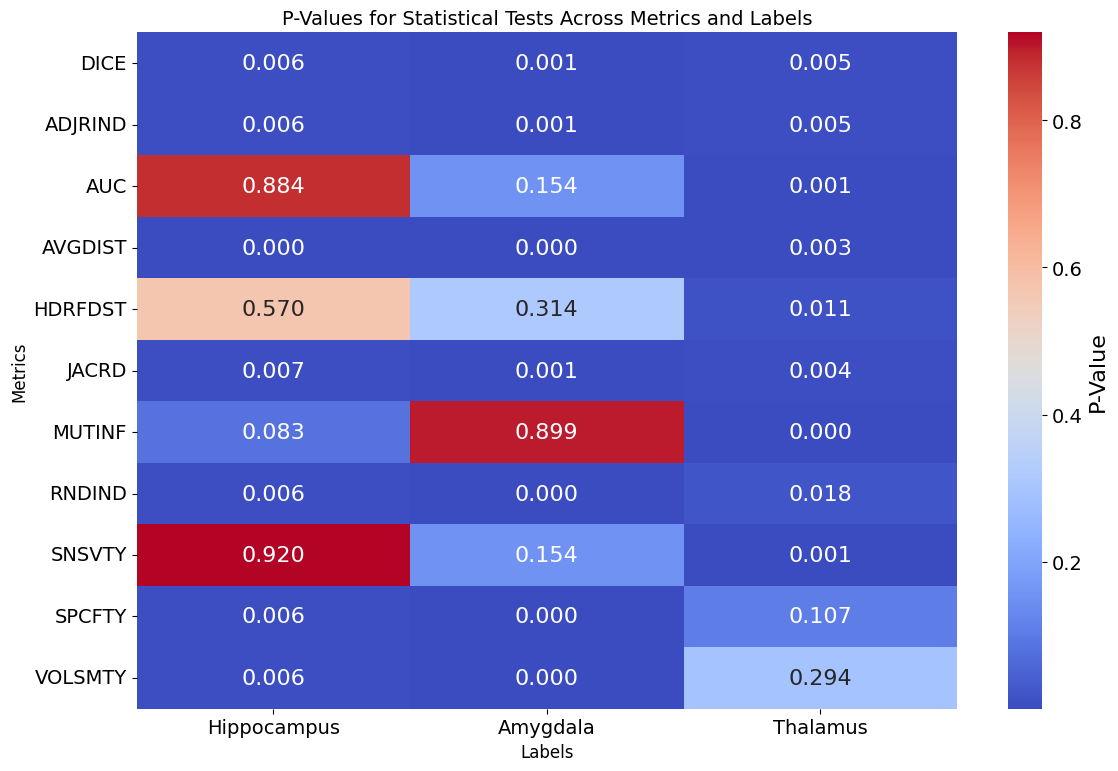

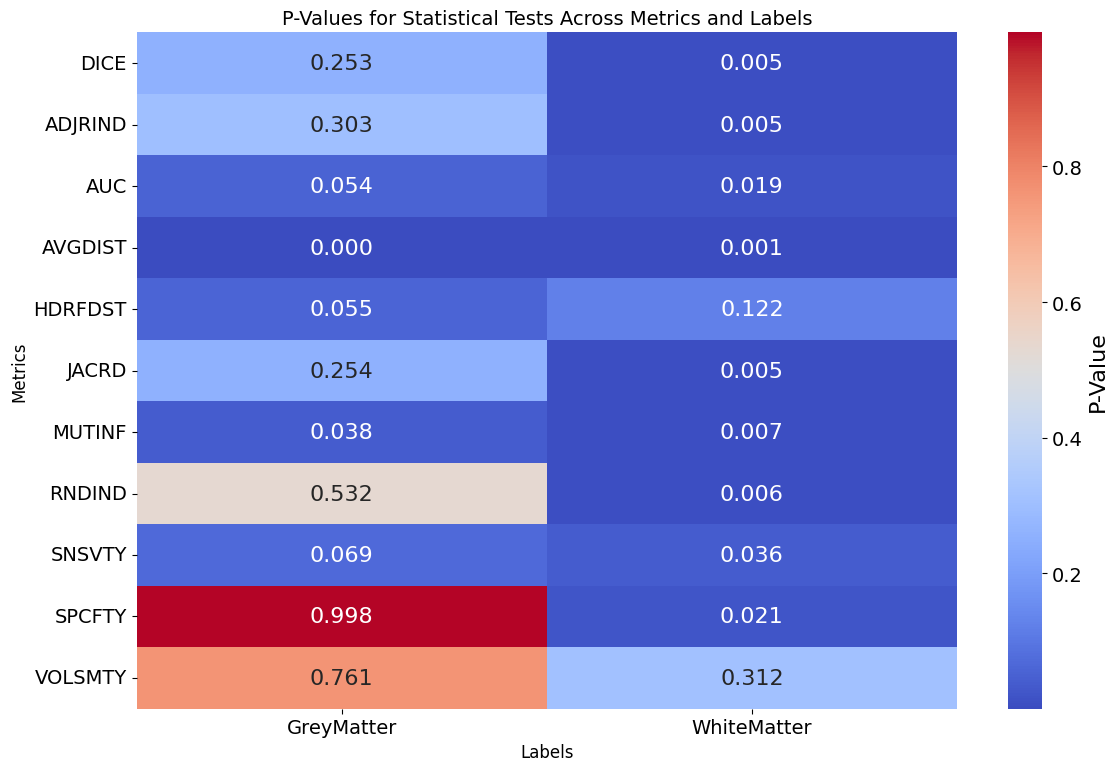

In [53]:
import seaborn as sns
import pandas as pd

def plot_pvalue_heatmap(test_results, labels, metrics):
    """
    Plots a heatmap of p-values across metrics and labels.
    """
    data = {label: [test_results[label][metric]['p_val'] for metric in metrics] for label in labels}
    df = pd.DataFrame(data, index=metrics)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(df, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={'label': 'P-Value'})
    plt.title("P-Values for Statistical Tests Across Metrics and Labels", fontsize=14)
    plt.xlabel("Labels", fontsize=12)
    plt.ylabel("Metrics", fontsize=12)
    plt.tight_layout()
    plt.show()

# Example usage
plot_pvalue_heatmap(small_test_results, small_labels, metrics_columns)
plot_pvalue_heatmap(large_test_results, large_labels, metrics_columns)


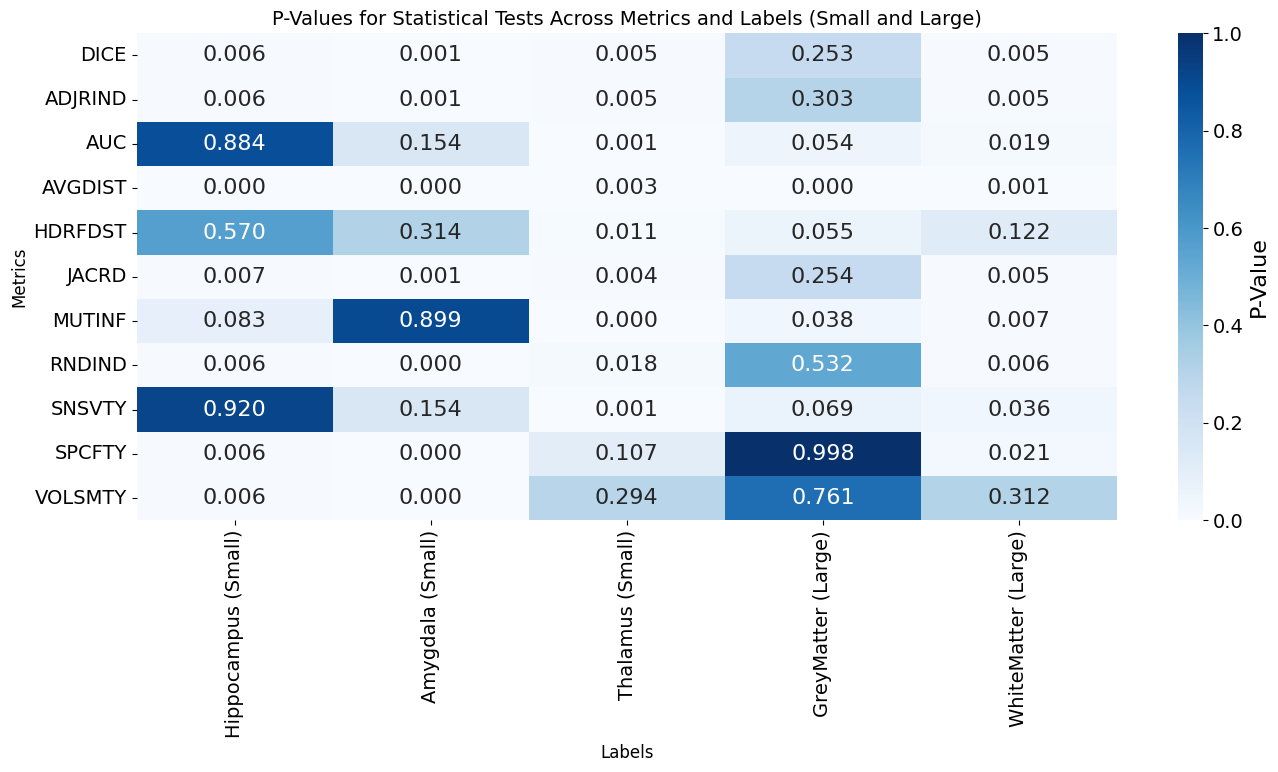

In [55]:
def plot_combined_pvalue_heatmap(small_results, large_results, small_labels, large_labels, metrics):
    """
    Plots a combined heatmap of p-values for both small and large structures across metrics.
    """
    # Combine results for small and large into a single DataFrame
    data = {}
    for label in small_labels:
        data[f"{label} (Small)"] = [small_results[label][metric]['p_val'] for metric in metrics]
    for label in large_labels:
        data[f"{label} (Large)"] = [large_results[label][metric]['p_val'] for metric in metrics]
    
    df = pd.DataFrame(data, index=metrics)
    
    # Plot the heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        df,
        annot=True,
        fmt=".3f",
        cmap="Blues",  # Use the blue colormap
        cbar_kws={'label': 'P-Value'},
        vmin=0, vmax=1  # Ensure consistent scaling for p-values between 0 and 1
    )
    plt.title("P-Values for Statistical Tests Across Metrics and Labels (Small and Large)", fontsize=14)
    plt.xlabel("Labels", fontsize=12)
    plt.ylabel("Metrics", fontsize=12)
    plt.tight_layout()
    plt.show()

# Example usage
plot_combined_pvalue_heatmap(small_test_results, large_test_results, small_labels, large_labels, metrics_columns)


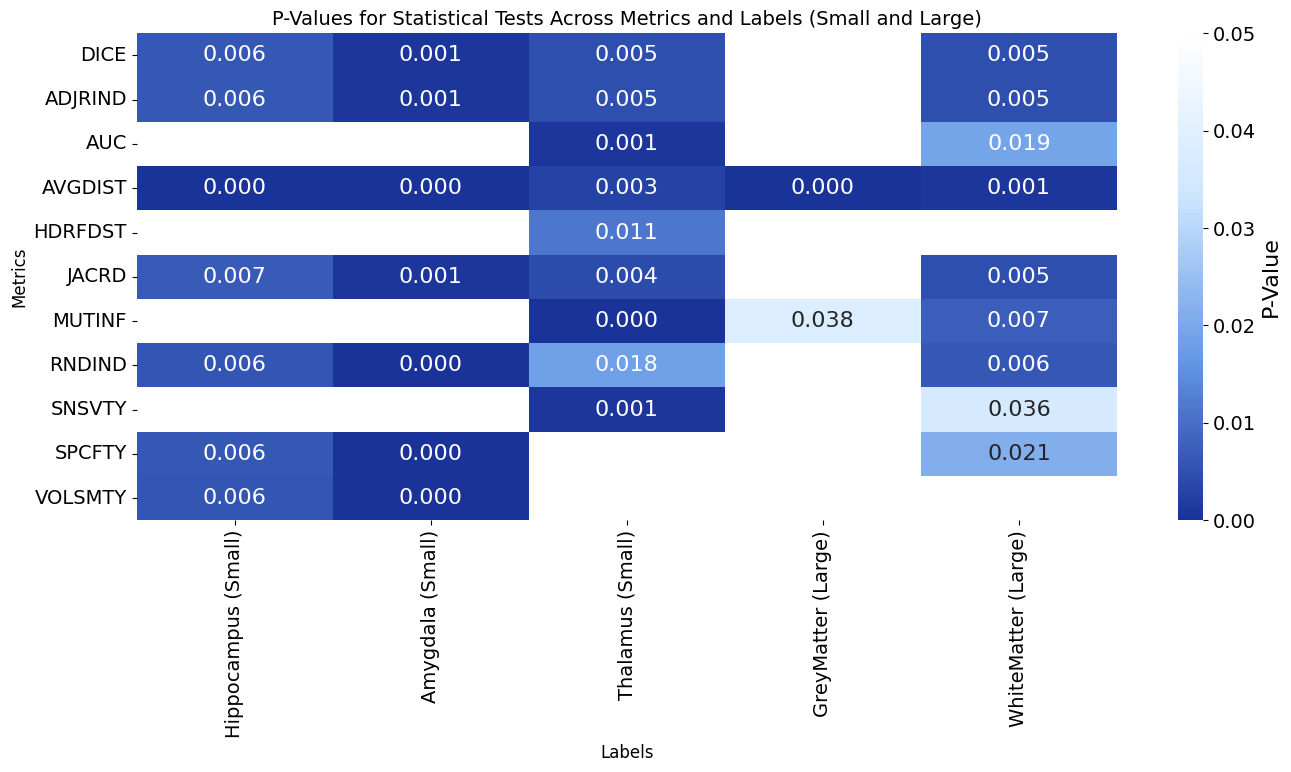

In [58]:
import matplotlib.colors as mcolors

def plot_combined_pvalue_heatmap(small_results, large_results, small_labels, large_labels, metrics):
    """
    Plots a combined heatmap of p-values for both small and large structures across metrics,
    with a gradient for p-values below 0.05 and white for values above 0.05.
    The gradient is reversed, with dark blue for low p-values and light blue for higher p-values.
    """
    # Combine results for small and large into a single DataFrame
    data = {}
    for label in small_labels:
        data[f"{label} (Small)"] = [small_results[label][metric]['p_val'] for metric in metrics]
    for label in large_labels:
        data[f"{label} (Large)"] = [large_results[label][metric]['p_val'] for metric in metrics]
    
    df = pd.DataFrame(data, index=metrics)
    
    # Create a custom reversed colormap: dark blue to light blue for p < 0.05, white for p >= 0.05
    colors = [(0.1, 0.2, 0.6), (0.4, 0.6, 0.9), (0.8, 0.9, 1), (1, 1, 1)]  # Dark blue to white
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue_reversed", colors, N=100)
    
    # Mask values above 0.05
    masked_df = df.copy()
    masked_df[df >= 0.05] = np.nan  # Mask p-values >= 0.05

    plt.figure(figsize=(14, 8))
    sns.heatmap(
        masked_df,
        annot=True,
        fmt=".3f",
        cmap=custom_cmap,
        cbar_kws={'label': 'P-Value'},
        vmin=0, vmax=0.05  # Limit the colormap to the range [0, 0.05]
    )
    plt.title("P-Values for Statistical Tests Across Metrics and Labels (Small and Large)", fontsize=14)
    plt.xlabel("Labels", fontsize=12)
    plt.ylabel("Metrics", fontsize=12)
    plt.tight_layout()
    plt.show()

# Example usage
plot_combined_pvalue_heatmap(small_test_results, large_test_results, small_labels, large_labels, metrics_columns)



# 5. Statistical significance of per metric across all labels:

In [69]:
# Function to test normality of metric differences for all labels combined
def test_normality_combined(data_all, data_spec, metrics_columns):
    normality_results = {}
    for metric in metrics_columns:
        all_values = data_all[metric].values
        spec_values = data_spec[metric].values
        # Compute differences
        differences = all_values - spec_values
        # Perform Shapiro-Wilk test
        stat, p = shapiro(differences)
        normality_results[metric] = p > 0.05  # True if normal distribution can be assumed
    
    return normality_results

# Function to perform paired t-tests or Wilcoxon signed-rank tests based on normality for all labels combined
def check_statistical_significance_combined(data_all, data_spec, metrics_columns, normality_results):
    results = {}
    for metric in metrics_columns:
        all_values = data_all[metric].values
        spec_values = data_spec[metric].values
        
        if normality_results[metric]:
            # Perform paired t-test
            t_stat, p_val = ttest_rel(spec_values, all_values)
            effect_size = cohen_d_paired(spec_values, all_values)
            test_name = 'Paired t-test'
        else:
            # Perform Wilcoxon signed-rank test
            t_stat, p_val = wilcoxon(spec_values, all_values)
            effect_size = rank_biserial_correlation(spec_values, all_values)
            test_name = 'Wilcoxon signed-rank test'
        
        significance = p_val < 0.05
        results[metric] = {'test': test_name, 't_stat': t_stat, 'p_val': p_val, 'effect_size': effect_size, 'significant': significance}
    return results


normality_results_combined = test_normality_combined(data_all, data_small, metrics_columns)
statistical_significance_results_combined = check_statistical_significance_combined(data_all, data_small, metrics_columns, normality_results_combined)
normality_results_combined_l = test_normality_combined(data_all, data_large, metrics_columns)
statistical_significance_results_combined_l = check_statistical_significance_combined(data_all, data_large, metrics_columns, normality_results_combined_l)
def display_significance_results(significance_results):
    for label, metrics in significance_results.items():
        print(f"\nStatistical Significance for Label: {label}")
        df = pd.DataFrame(metrics).T
        df['significant'] = df['significant'].map({True: 'Yes', False: 'No'})
        display(df)

# Print the results
def display_results_combined(statistical_significance_results, model_size):
    print(f"\nStatistical Significance Results for {model_size} Structures Optimised model (All Labels Combined):")
    df = pd.DataFrame(columns=['Metric', 'Test', 't_stat', 'p_val', 'Effect Size'])
    
    rows = []
    for metric, result in statistical_significance_results.items():
        rows.append({
            'Metric': metric,
            'Test': result['test'],
            't_stat': f"{result['t_stat']:.3f}",
            'p_val': f"{result['p_val']:.3f}",
            'Effect Size': f"{result['effect_size']:.3f}",
            'significant': f"{result['significant']}"
        })
    df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

    display(df)

display_results_combined(statistical_significance_results_combined, 'Small')
display_results_combined(statistical_significance_results_combined_l, 'Large')


Statistical Significance Results for Small Structures Optimised model (All Labels Combined):


,Metric,Test,t_stat,p_val,Effect Size,significant
0,ADJRIND,Wilcoxon signed-rank test,1199.000,0.000,-0.237,True
1,AUC,Wilcoxon signed-rank test,2319.000,0.479,-0.541,False
2,AVGDIST,Wilcoxon signed-rank test,1077.000,0.000,-0.787,True
3,DICE,Wilcoxon signed-rank test,1214.000,0.000,-0.240,True
4,FN,Wilcoxon signed-rank test,1790.500,0.024,-0.372,True
5,FP,Wilcoxon signed-rank test,1695.500,0.004,-0.664,True
6,HDRFDST,Wilcoxon signed-rank test,1734.000,0.557,-0.546,False
7,JACRD,Wilcoxon signed-rank test,1262.000,0.000,-0.250,True
8,MUTINF,Wilcoxon signed-rank test,2443.000,0.778,-0.516,False
9,PRCISON,Wilcoxon signed-rank test,1281.000,0.000,-0.254,True



Statistical Significance Results for Large Structures Optimised model (All Labels Combined):


,Metric,Test,t_stat,p_val,Effect Size,significant
0,ADJRIND,Wilcoxon signed-rank test,1306.000,0.000,-0.259,True
1,AUC,Wilcoxon signed-rank test,1320.000,0.000,-0.261,True
2,AVGDIST,Wilcoxon signed-rank test,936.000,0.000,-0.815,True
3,DICE,Wilcoxon signed-rank test,1307.000,0.000,-0.259,True
4,FN,Wilcoxon signed-rank test,1774.500,0.010,-0.648,True
5,FP,Wilcoxon signed-rank test,2195.000,0.257,-0.565,False
6,HDRFDST,Wilcoxon signed-rank test,1615.000,0.059,-0.607,False
7,JACRD,Wilcoxon signed-rank test,1342.000,0.000,-0.266,True
8,MUTINF,Wilcoxon signed-rank test,2013.000,0.078,-0.399,False
9,PRCISON,Wilcoxon signed-rank test,1490.000,0.000,-0.295,True


# Some random trials on the data 


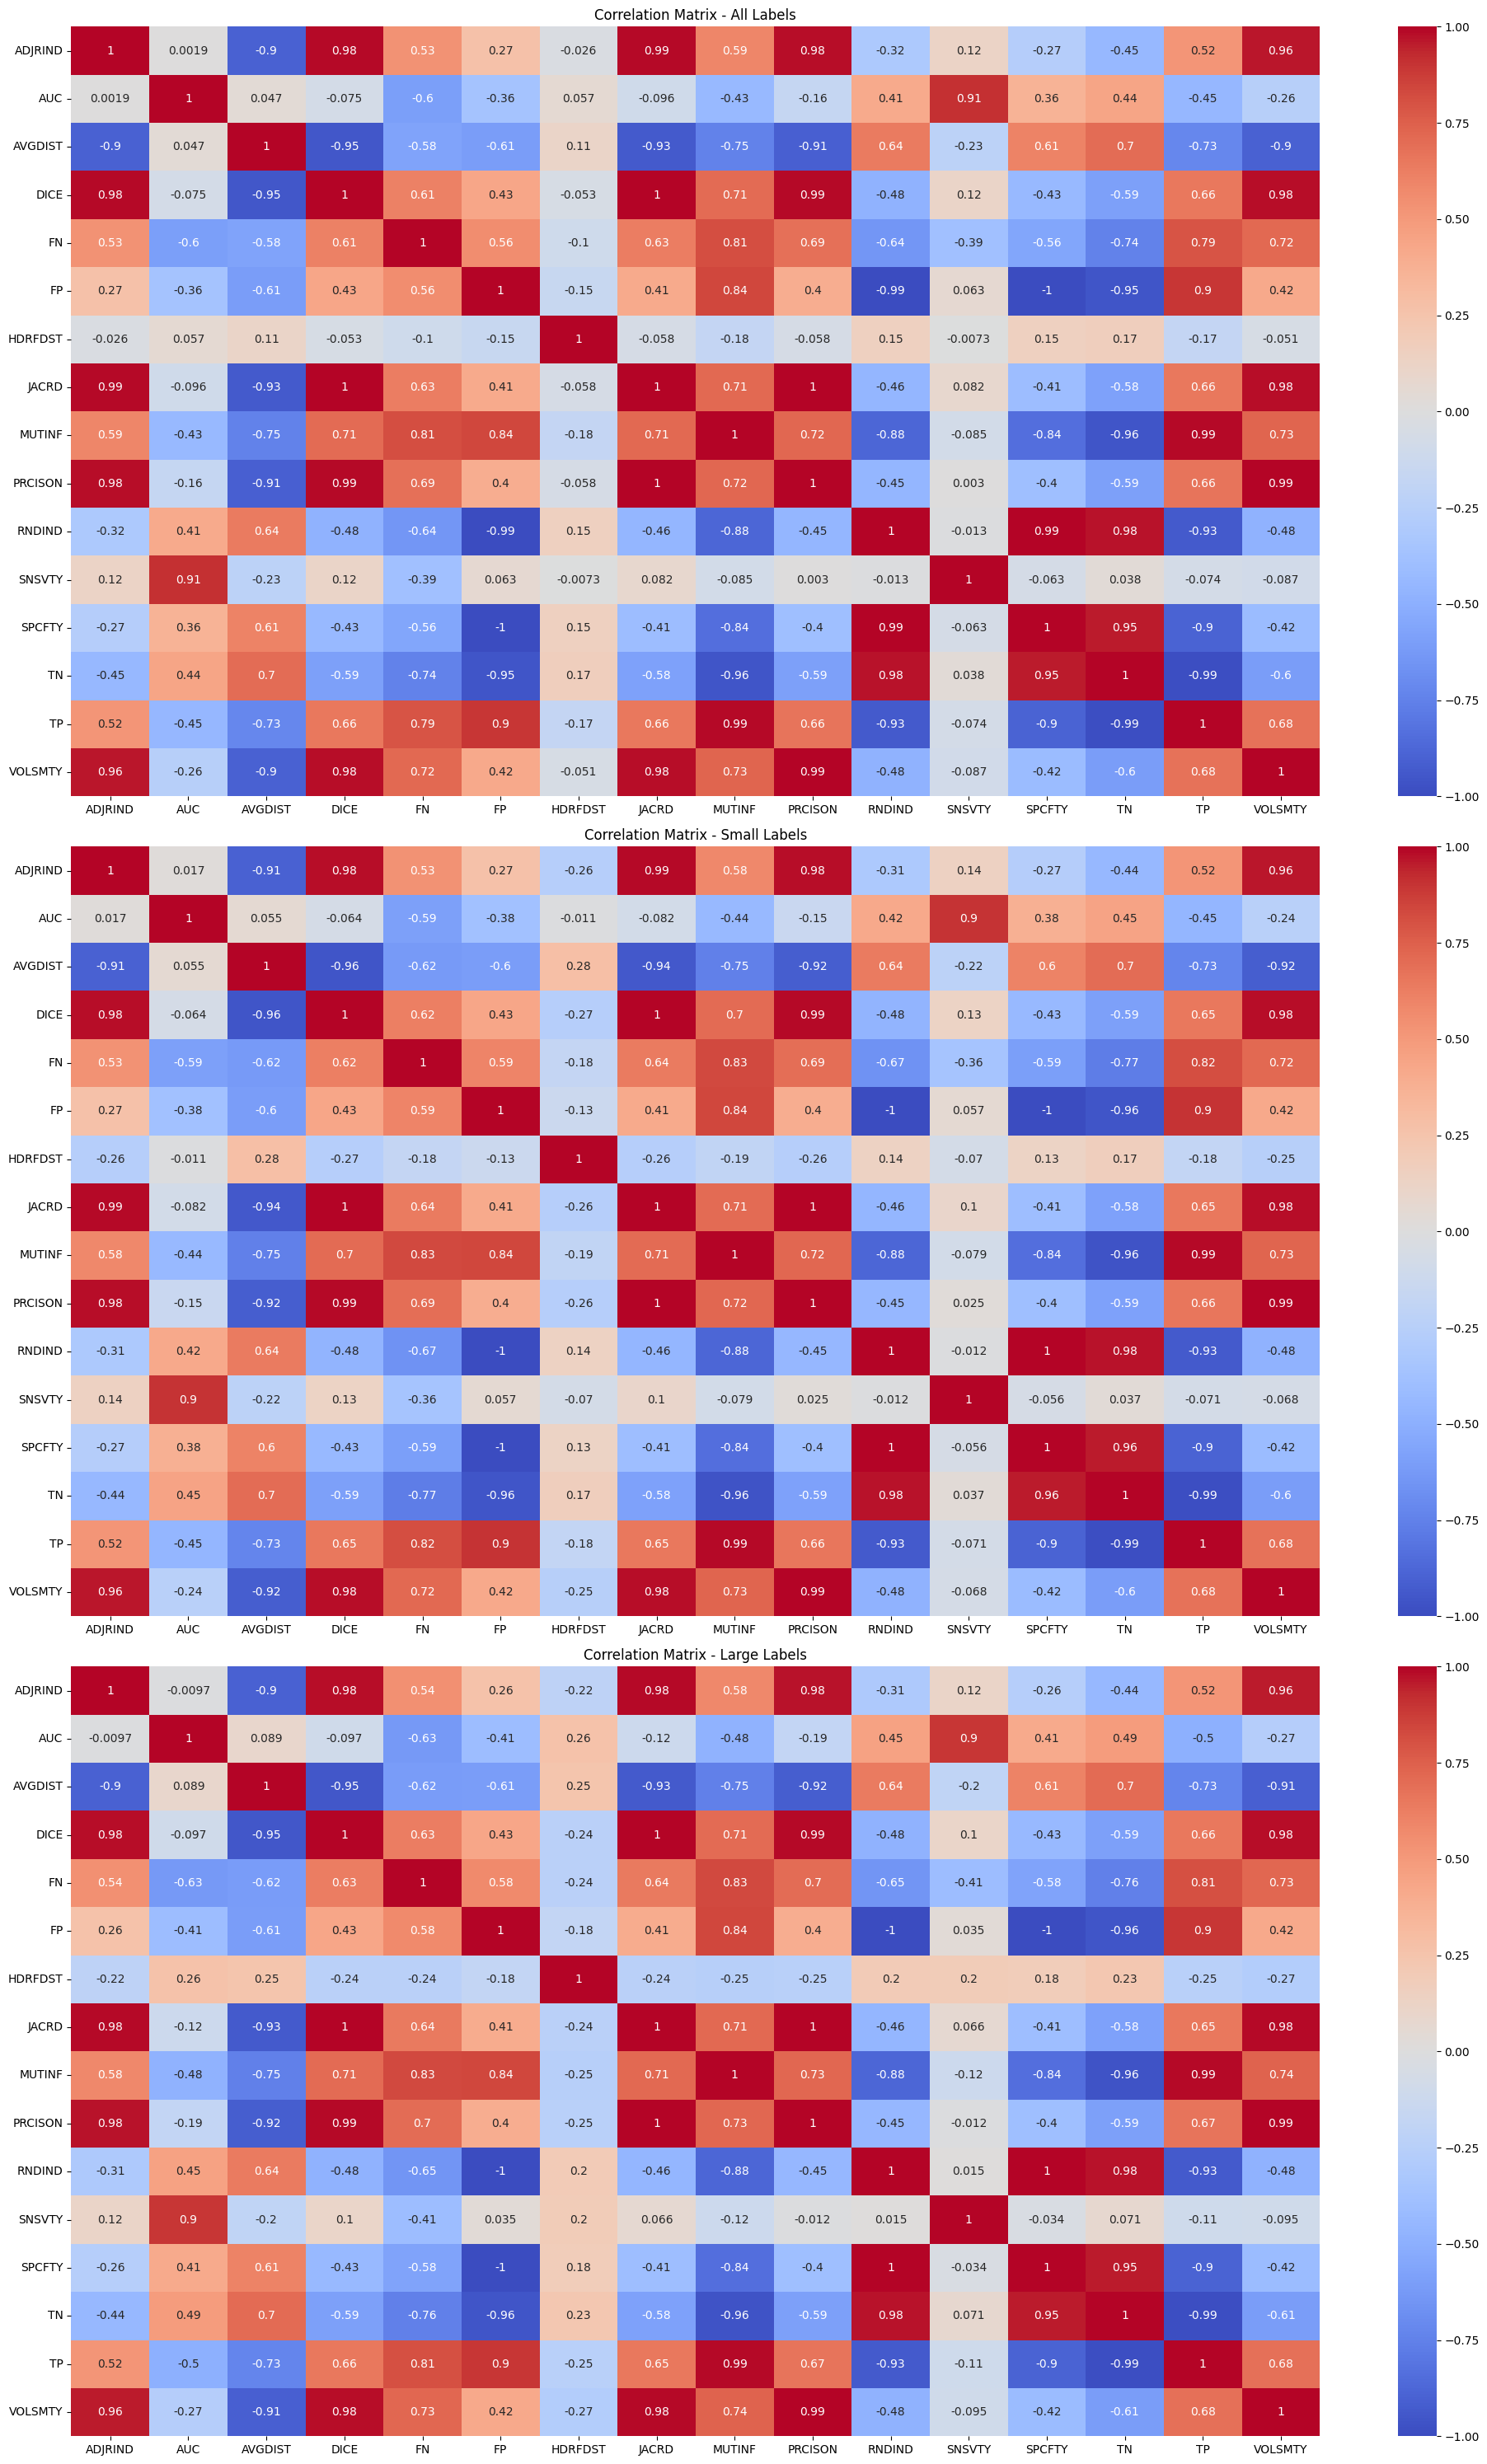

In [ ]:
# Select only the performance metrics columns
metrics_columns = ['ADJRIND', 'AUC', 'AVGDIST', 'DICE', 'FN', 'FP', 'HDRFDST', 'JACRD', 'MUTINF', 'PRCISON', 'RNDIND', 'SNSVTY', 'SPCFTY', 'TN', 'TP', 'VOLSMTY']

data_all_metrics = data_all[metrics_columns]
data_small_metrics = data_small[metrics_columns]
data_large_metrics = data_large[metrics_columns]

# Calculate correlation matrices
corr_all = data_all_metrics.corr()
corr_small = data_small_metrics.corr()
corr_large = data_large_metrics.corr()

# Plot correlation matrices
fig, axes = plt.subplots(3, 1, figsize=(20, 30))

sns.heatmap(corr_all, ax=axes[0], annot=True, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix - All Labels')

sns.heatmap(corr_small, ax=axes[1], annot=True, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('Correlation Matrix - Small Labels')

sns.heatmap(corr_large, ax=axes[2], annot=True, cmap='coolwarm', vmin=-1, vmax=1)
axes[2].set_title('Correlation Matrix - Large Labels')

plt.tight_layout()
plt.show()

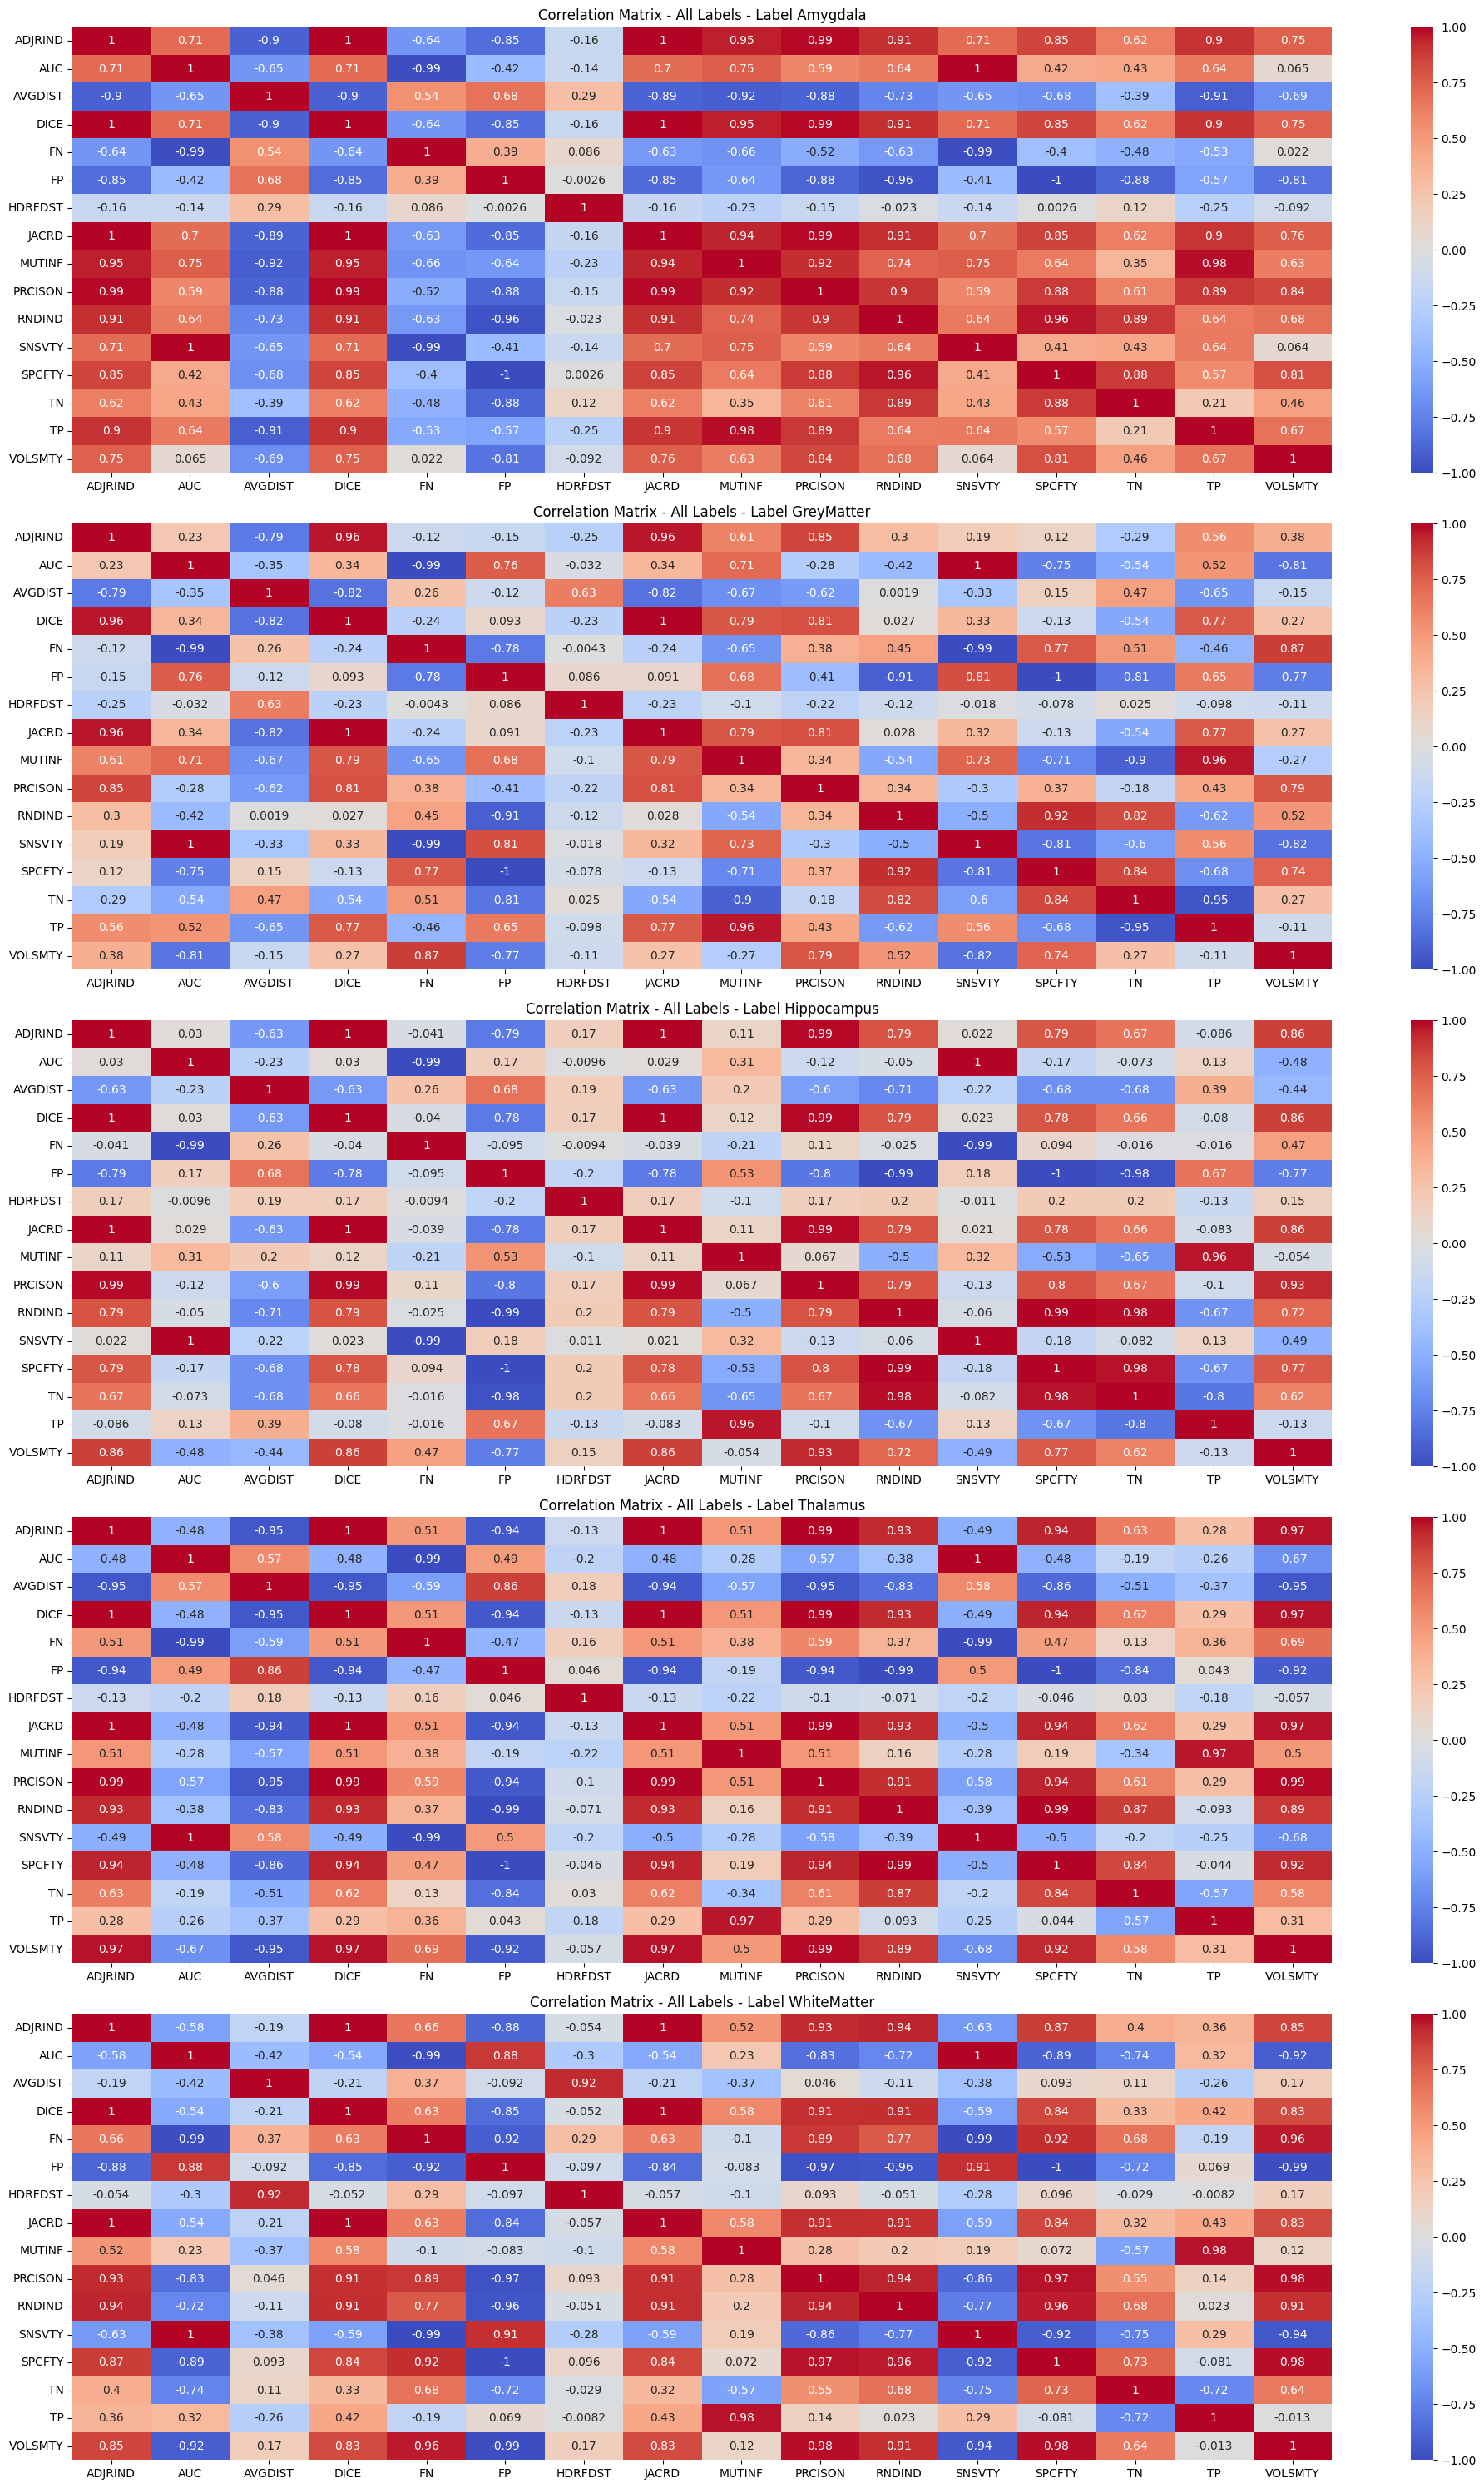

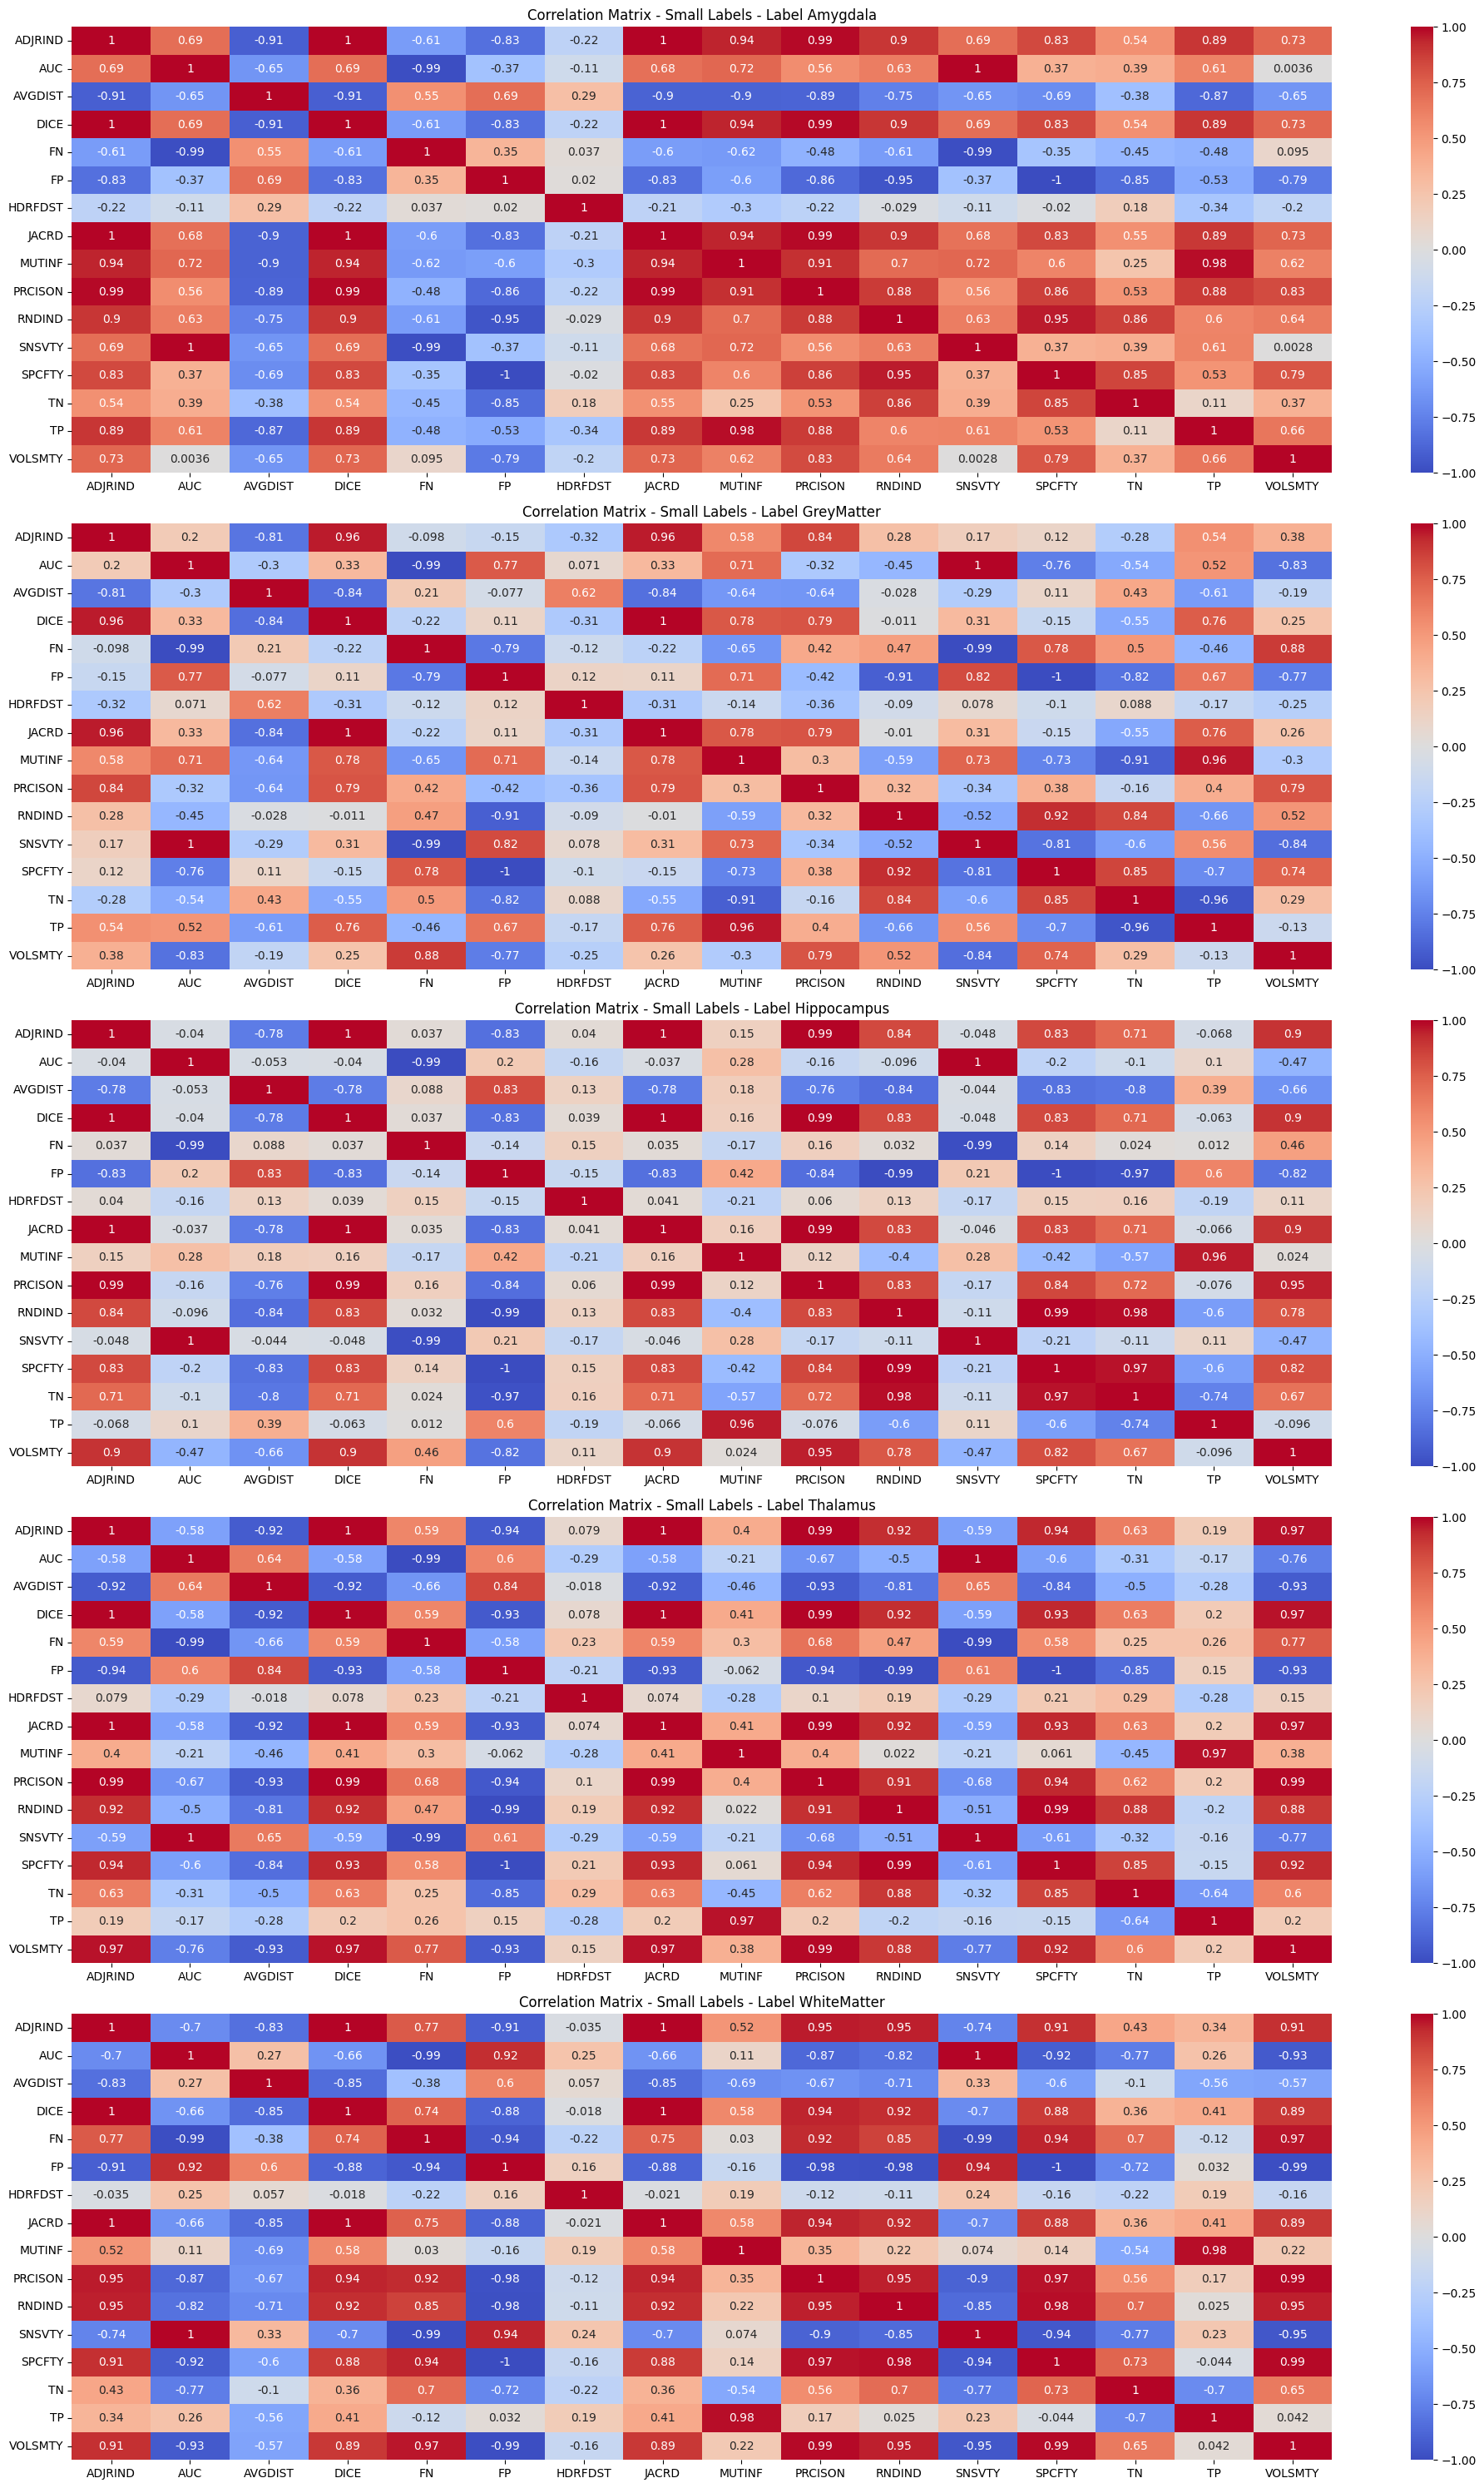

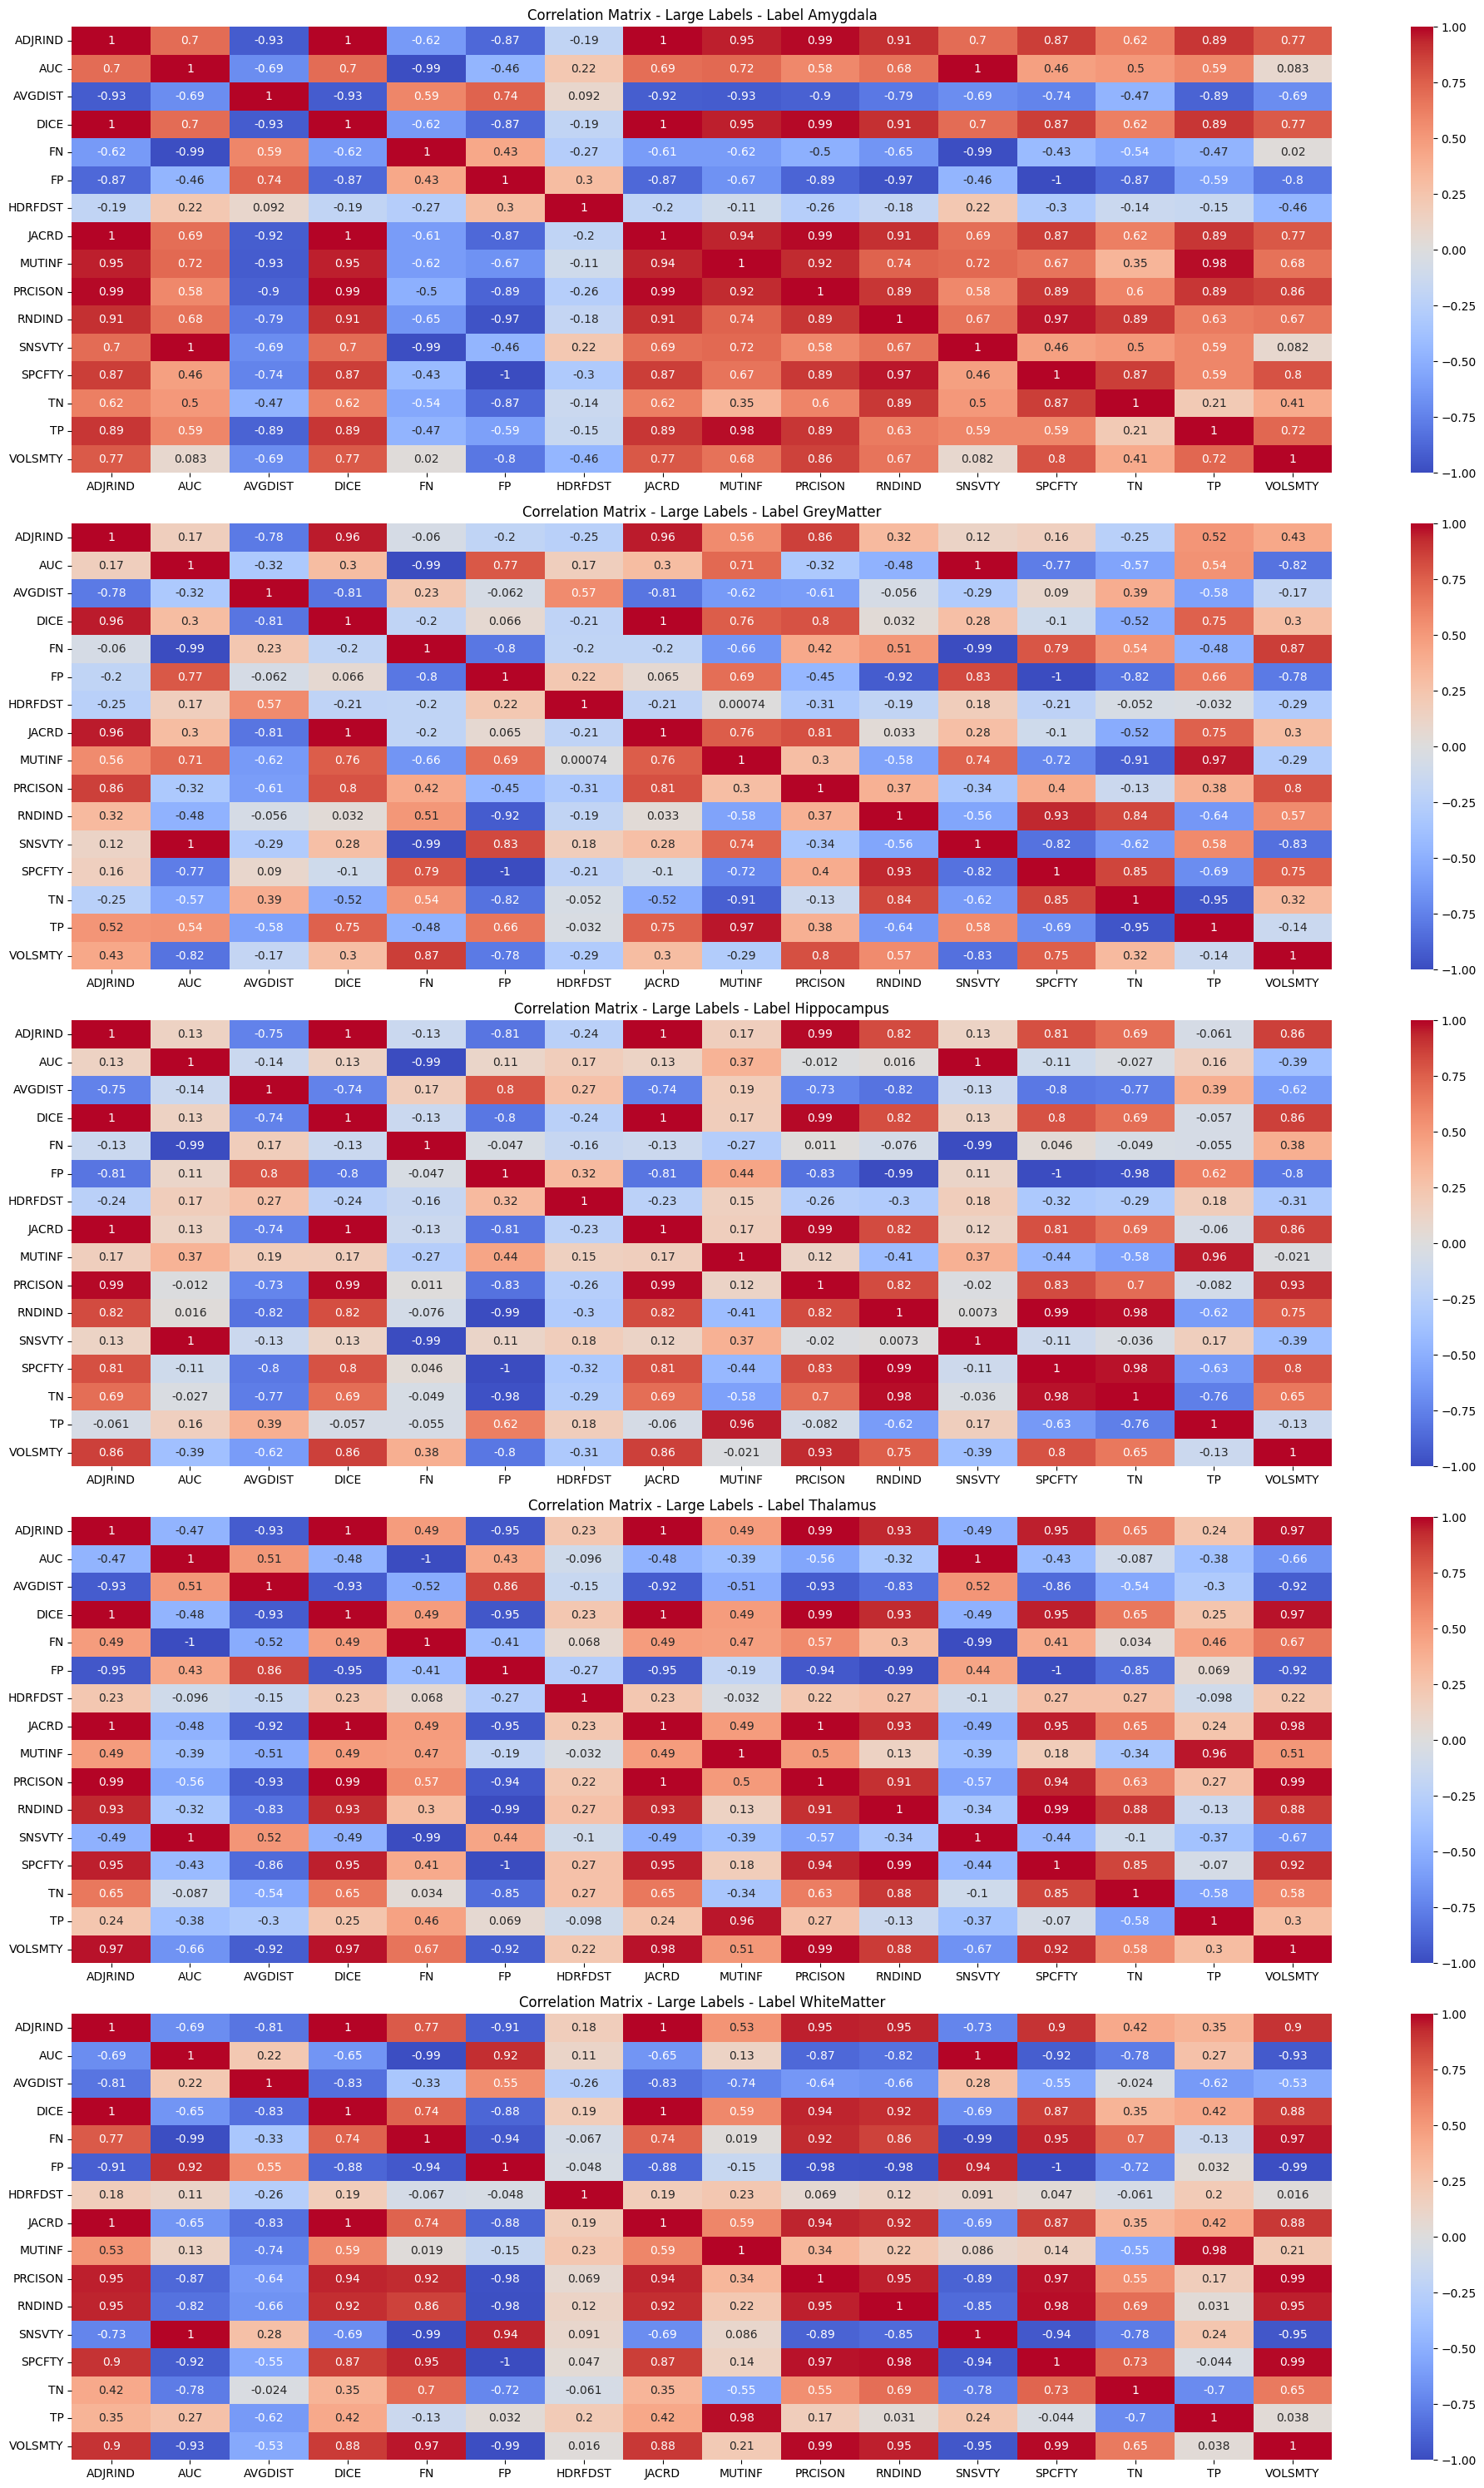

In [26]:
# Function to plot correlation matrices per label
def plot_correlation_matrices(data, title_prefix):
    labels = data['LABEL'].unique()
    fig, axes = plt.subplots(len(labels), 1, figsize=(20, 6 * len(labels)))
    
    for i, label in enumerate(labels):
        data_label = data[data['LABEL'] == label][metrics_columns]
        corr_matrix = data_label.corr()
        sns.heatmap(corr_matrix, ax=axes[i], annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        axes[i].set_title(f'{title_prefix} - Label {label}')
    
    plt.tight_layout()
    plt.show()

# Plot correlation matrices for each label in all datasets
plot_correlation_matrices(data_all, 'Correlation Matrix - All Labels')
plot_correlation_matrices(data_small, 'Correlation Matrix - Small Labels')
plot_correlation_matrices(data_large, 'Correlation Matrix - Large Labels')

In [76]:
# Calculate differences in performance metrics
differences = {}

for metric in metrics_columns:
    differences[f'{metric}_diff_small'] = data_all[metric] - data_small[metric]
    differences[f'{metric}_diff_large'] = data_all[metric] - data_large[metric]

diff_df = pd.DataFrame(differences)
diff_df['LABEL'] = data_all['LABEL']
diff_df['SUBJECT'] = data_all['SUBJECT']
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Normalize the performance metrics columns
data_all_metrics_normalized = pd.DataFrame(scaler.fit_transform(data_all_metrics), columns=metrics_columns)
data_small_metrics_normalized = pd.DataFrame(scaler.fit_transform(data_small_metrics), columns=metrics_columns)
data_large_metrics_normalized = pd.DataFrame(scaler.fit_transform(data_large_metrics), columns=metrics_columns)

# Normalize the differences dataframe
diff_df_normalized = pd.DataFrame(scaler.fit_transform(diff_df), columns=diff_df.columns)

diff_df.head()

ValueError: could not convert string to float: 'Amygdala'

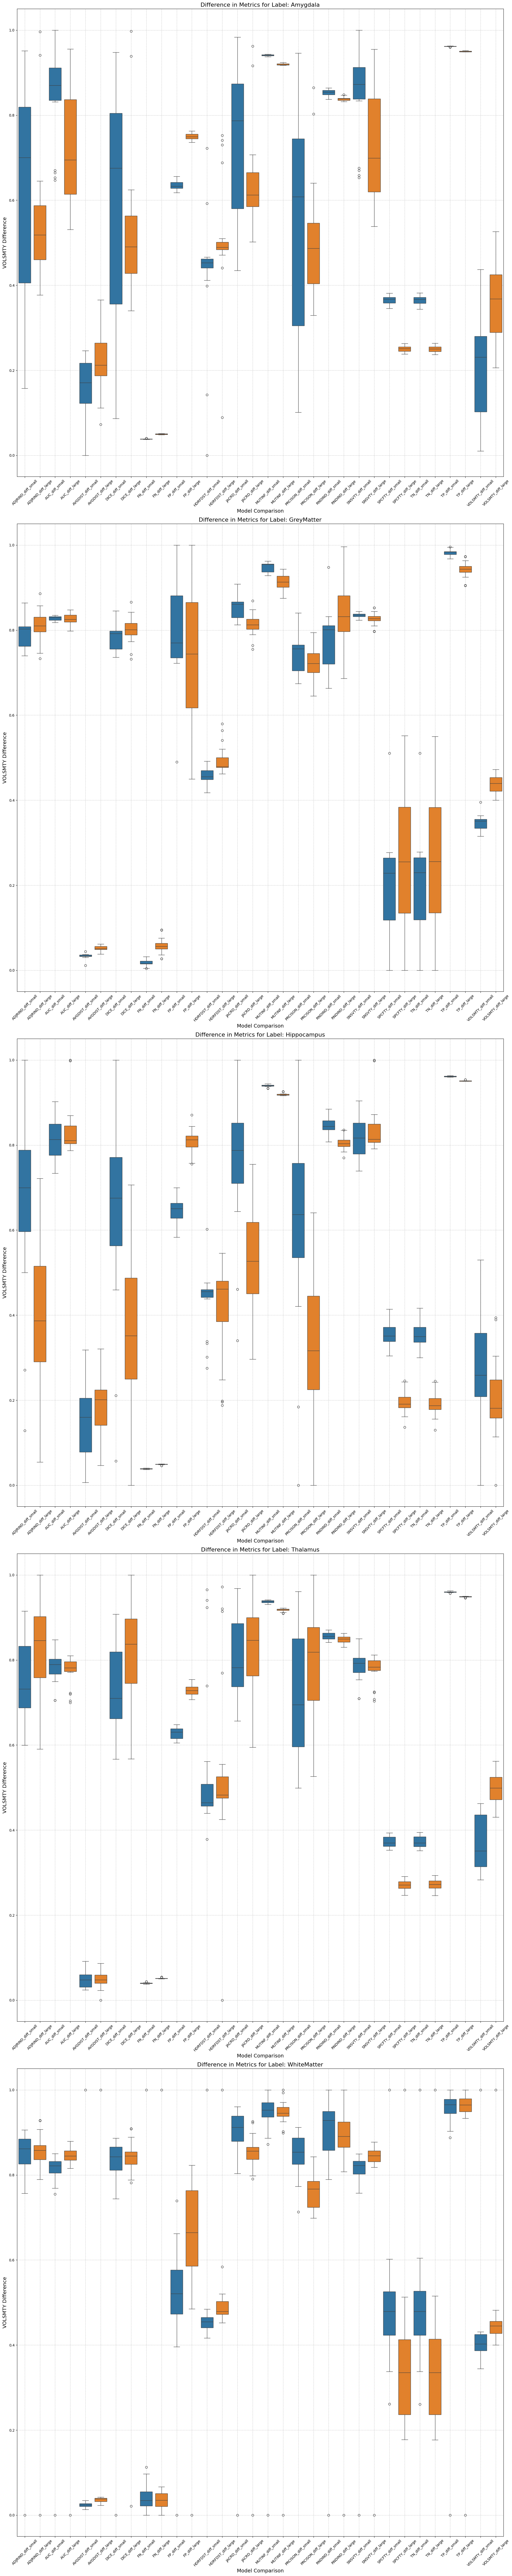

In [ ]:

corr_with_dice_small = data_small.drop(columns=['SUBJECT', 'LABEL', 'Model']).corr()['DICE']
corr_with_dice_large = data_large.drop(columns=['SUBJECT', 'LABEL', 'Model']).corr()['DICE']

print("Correlation with Dice Score (Small Labels):")
print(corr_with_dice_small)

print("\nCorrelation with Dice Score (Large Labels):")
print(corr_with_dice_large)

Correlation with Dice Score (Small Labels):
ADJRIND    0.984296
AUC       -0.064318
AVGDIST   -0.955318
DICE       1.000000
FN         0.619607
FP         0.431892
HDRFDST   -0.265457
JACRD      0.997642
MUTINF     0.704857
PRCISON    0.989435
RNDIND    -0.476288
SNSVTY     0.131767
SPCFTY    -0.431430
TN        -0.589986
TP         0.654057
VOLSMTY    0.979150
Name: DICE, dtype: float64

Correlation with Dice Score (Large Labels):
ADJRIND    0.983601
AUC       -0.097172
AVGDIST   -0.952658
DICE       1.000000
FN         0.625614
FP         0.430787
HDRFDST   -0.240512
JACRD      0.997568
MUTINF     0.707546
PRCISON    0.988904
RNDIND    -0.476740
SNSVTY     0.102088
SPCFTY    -0.430258
TN        -0.591197
TP         0.656112
VOLSMTY    0.979493
Name: DICE, dtype: float64


In [37]:
from scipy.stats import ttest_ind

# Perform t-tests to compare metrics between models
ttest_results = {}

for metric in metrics_columns:
    t_stat, p_val = ttest_ind(data_all[metric], data_small[metric])
    ttest_results[f'{metric}_all_vs_small'] = (t_stat, p_val)
    
    t_stat, p_val = ttest_ind(data_all[metric], data_large[metric])
    ttest_results[f'{metric}_all_vs_large'] = (t_stat, p_val)

ttest_df = pd.DataFrame(ttest_results, index=['t_stat', 'p_val']).T
print(ttest_df)

                        t_stat     p_val
ADJRIND_all_vs_small -0.155433  0.876639
ADJRIND_all_vs_large -0.212701  0.831779
AUC_all_vs_small     -0.055988  0.955408
AUC_all_vs_large     -0.369633  0.712051
AVGDIST_all_vs_small  0.508654  0.611561
AVGDIST_all_vs_large  0.635944  0.525547
DICE_all_vs_small    -0.140600  0.888329
DICE_all_vs_large    -0.195316  0.845346
FN_all_vs_small       0.059452  0.952652
FN_all_vs_large       0.084436  0.932795
FP_all_vs_small       0.013419  0.989307
FP_all_vs_large      -0.002545  0.997972
HDRFDST_all_vs_small  0.726188  0.468581
HDRFDST_all_vs_large  0.794400  0.427914
JACRD_all_vs_small   -0.124323  0.901186
JACRD_all_vs_large   -0.158306  0.874377
MUTINF_all_vs_small  -0.008614  0.993136
MUTINF_all_vs_large  -0.009752  0.992229
PRCISON_all_vs_small -0.106557  0.915248
PRCISON_all_vs_large -0.122011  0.903014
RNDIND_all_vs_small  -0.018613  0.985169
RNDIND_all_vs_large  -0.007347  0.994145
SNSVTY_all_vs_small  -0.054154  0.956867
SNSVTY_all_vs_la